Post-hoc evaluation of three trained segmentation models (brain specialist, pneumothorax specialist, mixed) under five conditions per modality. No retraining. No GT required for the reliability signal itself.

**Five cases evaluated (per modality):**
| # | Name | Model | Data |
|---|------|-------|------|
| 1 | Correct routing, clean | Specialist | Clean test |
| 2 | Mixed model, clean | Mixed | Clean test |
| 3 | Correct routing, noisy | Specialist | Noisy test |
| 4 | Mixed model, noisy | Mixed | Noisy test |
| 5 | Misroute (ablation) | Wrong specialist | Noisy test |
| 6 | Clean Misroute | Wrong specialist | Clean test |

**Reliability signal = Uncertainty (MC Dropout) + Plausibility (area + connectivity)**

In [4]:
!pip install segmentation_models_pytorch

In [5]:
import os, gc, warnings
warnings.filterwarnings('ignore')
os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '1'

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm.auto import tqdm
from typing import List, Tuple, Dict, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split

print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")


PyTorch : 2.9.0+cu126
CUDA    : True
GPU     : Tesla P100-PCIE-16GB


In [6]:

# ============================================================
# PART C CONFIG  —  edit these values freely
# ============================================================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# --- MC Dropout ---
N_MC = 5                  # stochastic forward passes

# --- Prediction threshold ---
THRESHOLD = 0.5

# --- Test-time noise (applied on-the-fly, never saved) ---
# Noise added in normalised space (values roughly in [-2, 2]).
NOISE_STD_MIN = 0.08      # Gaussian noise std — mild perturbation
NOISE_STD_MAX = 0.12      # upper bound for Gaussian noise std

# --- Per-modality plausibility thresholds ---
PLAUSIBILITY = {
    "lung":  {"area_min_ratio": 0.001, "max_components": 2},  # raised 2→3: bilateral/loculated pneumothorax
    "brain": {"area_min_ratio": 0.001, "max_components": 2},
}
# Global fallbacks (used where modality is not passed)
AREA_MIN_RATIO = 0.001
MAX_COMPONENTS = 10

# # --- Threshold calibration ---
U_THRESH_PERCENTILE  = 95   # p95 of clean-correct unc variance (principled baseline; not tuned on test data) #88
DS_THRESH_PERCENTILE = 87 #85

# --- Threshold calibration ---
# U_THRESH_PERCENTILE  = 97   # p95 of clean-correct unc variance (principled baseline; not tuned on test data) #88
# DS_THRESH_PERCENTILE = 89 #85


# --- Environment detection: Kaggle vs local ---
ON_KAGGLE = os.path.exists("/kaggle/input")
env_label = "Kaggle" if ON_KAGGLE else "Local"


# --- Dataset paths ---
LUNG_ROOT       = "/kaggle/input/datasets/vbookshelf/pneumothorax-chest-xray-images-and-masks/siim-acr-pneumothorax"
LUNG_IMAGES_DIR = "png_images"
LUNG_MASKS_DIR  = "png_masks"
BRAIN_ROOT      = "/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m"

if ON_KAGGLE:
    _KAGGLE_BASE = "/kaggle/input"

    BRAIN_ROOT   = f"{_KAGGLE_BASE}/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m"
    BRAIN_CKPT   = f"{_KAGGLE_BASE}/models/nuhalsharafi/segmentation-models-pytorchpytorch/pytorch/default/1/brain_mri_dice0.9104_iou0.8819_ep39.pth"
    MIXED_CKPT   = f"{_KAGGLE_BASE}/models/nuhalsharafi/segmentation-models-pytorchpytorch/pytorch/default/1/mixed_dice0.7961_iou0.7766.pth"
    PNEUMO_CKPT  = f"{_KAGGLE_BASE}/models/nuhalsharafi/segmentation-models-pytorchpytorch/pytorch/default/1/pneumo_dice0.8373_iou0.8138_ep22.pth"
else:
    _NB_DIR      = os.getcwd()   # Jupyter kernel cwd = notebook directory
    LUNG_ROOT    = os.path.join(_NB_DIR, "databases", "lung", "siim-acr-pneumothorax")
    BRAIN_ROOT   = os.path.join(_NB_DIR, "databases", "brain", "kaggle_3m")
    BRAIN_CKPT   = os.path.join(_NB_DIR, "brain_mri_output", "brain_mri_dice0.9104_iou0.8819_ep39.pth")
    MIXED_CKPT   = os.path.join(_NB_DIR, "mixed_output",     "mixed_dice0.7961_iou0.7766.pth")
    PNEUMO_CKPT  = os.path.join(_NB_DIR, "sota_output",      "pneumo_dice0.8373_iou0.8138_ep22.pth")

LUNG_IMAGES_DIR = "png_images"
LUNG_MASKS_DIR  = "png_masks"

# --- Splits (must match training to approximate the held-out test fold) ---
VAL_SPLIT  = 0.15
TEST_SPLIT = 0.15
SEED       = 42
BATCH_SIZE = 32

# np.random.seed(SEED)
# torch.manual_seed(SEED)

import random
import torch.backends.cudnn as cudnn

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
cudnn.deterministic = True
cudnn.benchmark = False

print(f"Environment : {env_label}")
print(f"Device      : {DEVICE}")
print(f"N_MC        : {N_MC}")
print(f"\nNormalisation: norm05 (brain/pneumo specialists) | zscore (mixed model)")
print(f"\nDataset paths:")
print(f"  Lung  : {LUNG_ROOT}  [exists={os.path.exists(LUNG_ROOT)}]")
print(f"  Brain : {BRAIN_ROOT}  [exists={os.path.exists(BRAIN_ROOT)}]")
print(f"\nCheckpoints:")
for name, path in [("Brain", BRAIN_CKPT), ("Mixed", MIXED_CKPT), ("Pneumo", PNEUMO_CKPT)]:
    print(f"  {name:12s}: {path}  [exists={os.path.exists(path)}]")


Environment : Kaggle
Device      : cuda
N_MC        : 5

Normalisation: norm05 (brain/pneumo specialists) | zscore (mixed model)

Dataset paths:
  Lung  : /kaggle/input/datasets/vbookshelf/pneumothorax-chest-xray-images-and-masks/siim-acr-pneumothorax  [exists=True]
  Brain : /kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m  [exists=True]

Checkpoints:
  Brain       : /kaggle/input/models/nuhalsharafi/segmentation-models-pytorchpytorch/pytorch/default/1/brain_mri_dice0.9104_iou0.8819_ep39.pth  [exists=True]
  Mixed       : /kaggle/input/models/nuhalsharafi/segmentation-models-pytorchpytorch/pytorch/default/1/mixed_dice0.7961_iou0.7766.pth  [exists=True]
  Pneumo      : /kaggle/input/models/nuhalsharafi/segmentation-models-pytorchpytorch/pytorch/default/1/pneumo_dice0.8373_iou0.8138_ep22.pth  [exists=True]


In [7]:
# ============================================================
# MODEL BUILDER + CHECKPOINT LOADING
# ============================================================

import os
import torch
import torch.nn as nn
import segmentation_models_pytorch as smp
from typing import Tuple, Dict

# ------------------------------------------------------------
# FORCE the correct checkpoint paths here
# ------------------------------------------------------------
BRAIN_CKPT  = "/kaggle/input/models/nuhalsharafi/segmentation-models-pytorchpytorch/pytorch/default/1/brain_mri_dice0.9104_iou0.8819_ep39.pth"
MIXED_CKPT  = "/kaggle/input/models/nuhalsharafi/segmentation-models-pytorchpytorch/pytorch/default/1/mixed_dice0.7961_iou0.7766.pth"
PNEUMO_CKPT = "/kaggle/input/models/nuhalsharafi/segmentation-models-pytorchpytorch/pytorch/default/1/pneumo_dice0.8373_iou0.8138_ep22.pth"

# # --- Checkpoint paths ---
# BRAIN_CKPT      = "/kaggle/input/datasets/featherybatarde/models/brain_mri_dice0.9104_iou0.8819_ep39.pth"
# MIXED_CKPT      = "/kaggle/input/datasets/featherybatarde/models/mixed_dice0.7961_iou0.7766.pth"
# PNEUMO_CKPT     = "/kaggle/input/datasets/featherybatarde/models/pneumo_dice0.8373_iou0.8138_ep22.pth"
# # CLASSIFIER_CKPT = "/kaggle/input/datasets/featherybatarde/kkkkkkkkkkkkkk/best_model_f11.0000.pth"


print("BRAIN_CKPT :", BRAIN_CKPT)
print("MIXED_CKPT :", MIXED_CKPT)
print("PNEUMO_CKPT:", PNEUMO_CKPT)

assert os.path.exists(BRAIN_CKPT), f"Missing: {BRAIN_CKPT}"
assert os.path.exists(MIXED_CKPT), f"Missing: {MIXED_CKPT}"
assert os.path.exists(PNEUMO_CKPT), f"Missing: {PNEUMO_CKPT}"

print("\nAll checkpoint paths exist ✓")


def build_unetpp(encoder: str = "efficientnet-b1",
                 in_channels: int = 3,
                 decoder_dropout: float = 0.1,
                 decoder_attention_type=None) -> nn.Module:
    return smp.UnetPlusPlus(
        encoder_name=encoder,
        encoder_weights=None,
        in_channels=in_channels,
        classes=1,
        activation=None,
        decoder_attention_type=decoder_attention_type,
        decoder_dropout=decoder_dropout,
    )


def _infer_attention_type(state: dict):
    for k in state.keys():
        if ".cSE." in k or ".sSE." in k:
            return "scse"
    return None


def _infer_in_channels(state: dict, default: int = 3) -> int:
    candidates = [
        "encoder._conv_stem.weight",
        "encoder.conv1.weight",
        "encoder.features.0.0.weight",
        "encoder.layer0.conv1.weight",
    ]
    for key in candidates:
        if key in state:
            return int(state[key].shape[1])
    for k, v in state.items():
        if k.startswith("encoder.") and v.ndim == 4:
            return int(v.shape[1])
    return default


def load_checkpoint(ckpt_path: str,
                    device: str,
                    default_image_size: int = 256,
                    norm_mode: str = 'norm05') -> Tuple[nn.Module, int, Dict]:
    print(f"\nTrying to load checkpoint: {ckpt_path}")
    assert os.path.exists(ckpt_path), f"Checkpoint not found: {ckpt_path}"

    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    state = ckpt.get("model_state_dict", ckpt)

    encoder     = ckpt.get("encoder", "efficientnet-b1")
    image_size  = ckpt.get("image_size", ckpt.get("patch_size", default_image_size))
    in_channels = ckpt.get("in_channels", _infer_in_channels(state))
    attn_type   = ckpt.get("decoder_attention_type", _infer_attention_type(state))

    print(f"  encoder={encoder}, image_size={image_size}, in_channels={in_channels}, attention={attn_type}")

    model = build_unetpp(
        encoder=encoder,
        in_channels=in_channels,
        decoder_attention_type=attn_type
    )

    missing, unexpected = model.load_state_dict(state, strict=True)
    assert len(missing) == 0, f"Missing keys in {ckpt_path}:\n{missing}"
    assert len(unexpected) == 0, f"Unexpected keys in {ckpt_path}:\n{unexpected}"

    model.to(device).eval()

    meta = {
        "encoder": encoder,
        "image_size": image_size,
        "in_channels": in_channels,
        "decoder_attention": attn_type,
        "val_dice": ckpt.get("val_dice", None),
        "val_iou": ckpt.get("val_iou", None),
        "epoch": ckpt.get("epoch", None),
        "norm_mode": norm_mode,
        "ckpt_path": ckpt_path,
    }
    return model, image_size, meta


def scan_dropout(model: nn.Module) -> bool:
    for m in model.modules():
        if isinstance(m, (nn.Dropout, nn.Dropout2d)):
            return True
    return False


# ------------------------------------------------------------
# LOAD ALL THREE CHECKPOINTS
# ------------------------------------------------------------
print("\nLoading checkpoints …")
brain_model,  brain_sz,  brain_meta  = load_checkpoint(BRAIN_CKPT,  DEVICE, norm_mode='norm05')
mixed_model,  mixed_sz,  mixed_meta  = load_checkpoint(MIXED_CKPT,  DEVICE, norm_mode='zscore')
pneumo_model, pneumo_sz, pneumo_meta = load_checkpoint(PNEUMO_CKPT, DEVICE, default_image_size=512, norm_mode='norm05')

MODELS = {
    "brain":  (brain_model,  brain_sz),
    "mixed":  (mixed_model,  mixed_sz),
    "pneumo": (pneumo_model, pneumo_sz),
}

# ------------------------------------------------------------
# REPORT
# ------------------------------------------------------------
print(f"\n{'Model':<8} {'Encoder':<18} {'Size':>5} {'InCh':>4} {'Norm':<8} {'Dice':>6} {'IoU':>6}  {'Dropout?':<10}  Strategy")
print("-" * 100)

for name, (model, sz) in MODELS.items():
    meta = {"brain": brain_meta, "mixed": mixed_meta, "pneumo": pneumo_meta}[name]
    has_do = scan_dropout(model)
    strat = "MC Dropout" if has_do else "TTA Disagree"
    d = meta["val_dice"] or 0.0
    i = meta["val_iou"] or 0.0

    print(
        f"{name:<8} {meta['encoder']:<18} {sz:>5} {meta['in_channels']:>4} "
        f"{meta['norm_mode']:<8} {d:>6.4f} {i:>6.4f}  {str(has_do):<10}  {strat}"
    )

# ------------------------------------------------------------
# SANITY FORWARD PASS
# ------------------------------------------------------------
print("\nSanity forward passes …")
for name, (model, sz) in MODELS.items():
    ch = {"brain": brain_meta, "mixed": mixed_meta, "pneumo": pneumo_meta}[name]["in_channels"]
    dummy = torch.zeros(2, ch, sz, sz, device=DEVICE)

    with torch.no_grad():
        out = model(dummy)

    assert out.shape == (2, 1, sz, sz), \
        f"{name}: expected output (2,1,{sz},{sz}), got {tuple(out.shape)}"

    print(f"  {name}: {list(dummy.shape)} -> {list(out.shape)} ✓")

print("\nAll models ready.")

BRAIN_CKPT : /kaggle/input/models/nuhalsharafi/segmentation-models-pytorchpytorch/pytorch/default/1/brain_mri_dice0.9104_iou0.8819_ep39.pth
MIXED_CKPT : /kaggle/input/models/nuhalsharafi/segmentation-models-pytorchpytorch/pytorch/default/1/mixed_dice0.7961_iou0.7766.pth
PNEUMO_CKPT: /kaggle/input/models/nuhalsharafi/segmentation-models-pytorchpytorch/pytorch/default/1/pneumo_dice0.8373_iou0.8138_ep22.pth

All checkpoint paths exist ✓

Loading checkpoints …

Trying to load checkpoint: /kaggle/input/models/nuhalsharafi/segmentation-models-pytorchpytorch/pytorch/default/1/brain_mri_dice0.9104_iou0.8819_ep39.pth
  encoder=efficientnet-b3, image_size=256, in_channels=1, attention=scse

Trying to load checkpoint: /kaggle/input/models/nuhalsharafi/segmentation-models-pytorchpytorch/pytorch/default/1/mixed_dice0.7961_iou0.7766.pth
  encoder=efficientnet-b1, image_size=256, in_channels=3, attention=None

Trying to load checkpoint: /kaggle/input/models/nuhalsharafi/segmentation-models-pytorchpyt

In [8]:
# ============================================================
# DATASET CLASSES  (match training preprocessing exactly)
# ============================================================

def _max_pool_downsample_mask(mask: np.ndarray, target_size: int) -> np.ndarray:
    """Max-pool downsampling to preserve small positive regions."""
    h, w = mask.shape
    if h == target_size and w == target_size:
        return mask
    ratio = h // target_size
    if ratio > 1 and h % target_size == 0 and w % target_size == 0:
        return mask.reshape(target_size, ratio, target_size, ratio).max(axis=(1, 3))
    return cv2.resize(mask, (target_size, target_size), interpolation=cv2.INTER_NEAREST)


class SegDataset(Dataset):
    """
    Unified dataset for lung PNGs and brain TIFs.
    norm_mode:
        'norm05'  — (x/255 - 0.5) / 0.5 → [-1, 1]
                    matches A.Normalize(mean=(0.5,0.5,0.5), std=(0.5,0.5,0.5))
                    used by BOTH specialists (brain + pneumo)
        'zscore'  — per-image z-score; used by mixed model
    mask_threshold: 127 for lung (bright=positive), 0 for brain (any pixel).
    out_channels: 1 for grayscale models (brain specialist),
                  3 for RGB-replicated models (pneumo specialist, mixed model).
    """
    def __init__(self,
                 image_mask_pairs: List[Tuple[str, str]],
                 image_size: int = 256,
                 mask_threshold: int = 127,
                 out_channels: int = 3,
                 transform=None,
                 norm_mode: str = 'norm05'):
        self.pairs          = image_mask_pairs
        self.image_size     = image_size
        self.mask_threshold = mask_threshold
        self.out_channels   = out_channels
        self.transform      = transform
        self.norm_mode      = norm_mode   # 'norm05' | 'zscore'

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx: int):
        img_path, mask_path = self.pairs[idx]

        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        mask  = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if image is None:
            raise FileNotFoundError(f"Cannot load image: {img_path}")
        if mask is None:
            mask = np.zeros_like(image)

        image = cv2.resize(image, (self.image_size, self.image_size))
        mask  = _max_pool_downsample_mask(mask, self.image_size)
        mask  = (mask > self.mask_threshold).astype(np.float32)

        x = image.astype(np.float32)

        # --- Normalise ---
        if self.norm_mode == 'norm05':
            # Matches A.Normalize(mean=(0.5,0.5,0.5), std=(0.5,0.5,0.5))
            # A.Normalize divides by max_pixel_value=255 first, then applies mean/std
            # Result: (x/255 - 0.5) / 0.5  →  maps [0,255] to [-1, 1]
            x = (x / 255.0 - 0.5) / 0.5
        else:  # 'zscore' — per-image z-score (mixed model)
            x = (x - x.mean()) / (x.std() + 1e-6)

        # --- Channel expansion ---
        if self.out_channels == 1:
            x = x[:, :, np.newaxis]           # [H, W, 1]  — brain specialist
        else:
            x = np.stack([x, x, x], axis=-1)  # [H, W, 3]  — pneumo / mixed

        mask = np.expand_dims(mask, axis=-1)  # [H, W, 1]

        if self.transform is not None:
            out = self.transform(image=x, mask=mask)
            x, mask = out["image"], out["mask"]

        if mask.dim() == 3:
            mask = mask.permute(2, 0, 1)
        else:
            mask = mask.unsqueeze(0)

        return x, mask   # [C,H,W], [1,H,W]


class NoisyDataset(Dataset):
    """
    Wraps a SegDataset and adds mild Gaussian noise on-the-fly to the image tensor.
    Noise is NOT saved to disk. Image size is unchanged.
    Uses an isolated instance-level RNG (np.random.default_rng) so noise std
    sampling does not pollute or depend on the global numpy random state,
    ensuring reproducibility across re-runs.
    """
    def __init__(self,
                 base_dataset: SegDataset,
                 noise_std_min: float = NOISE_STD_MIN,
                 noise_std_max: float = NOISE_STD_MAX,
                 seed: int = SEED):
        self.base    = base_dataset
        self.std_min = noise_std_min
        self.std_max = noise_std_max
        self._rng    = np.random.default_rng(seed)  # isolated, reproducible
        # self._torch_gen = torch.Generator()
        # self._torch_gen.manual_seed(seed)  # seeded generator for torch.randn

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx: int):
        image, mask = self.base[idx]
        std   = float(self._rng.uniform(self.std_min, self.std_max))
        # noise = torch.randn(image.shape, generator=self._torch_gen) * std
        g = torch.Generator()
        g.manual_seed(SEED + idx)
        noise = torch.randn_like(image) * std
        return image + noise, mask


# --- Clean transform (val/test pipeline from training) ---
def get_clean_transform():
    return A.Compose([ToTensorV2()])


print("Dataset classes defined.")
print("  norm_mode='norm05' : (x/255-0.5)/0.5 → [-1,1]  ← brain & pneumo specialists")
print("  norm_mode='zscore' : per-image z-score           ← mixed model")
print("  out_channels=1 → [H,W,1] (brain specialist)")
print("  out_channels=3 → [H,W,3] (pneumo specialist / mixed model)")
print("  NoisyDataset uses isolated instance-level RNG (seed=SEED)")

Dataset classes defined.
  norm_mode='norm05' : (x/255-0.5)/0.5 → [-1,1]  ← brain & pneumo specialists
  norm_mode='zscore' : per-image z-score           ← mixed model
  out_channels=1 → [H,W,1] (brain specialist)
  out_channels=3 → [H,W,3] (pneumo specialist / mixed model)
  NoisyDataset uses isolated instance-level RNG (seed=SEED)


In [9]:
# ============================================================
# BUILD DATA PAIRS + DATALOADERS
# ============================================================

def find_lung_pairs(root: str, images_dir: str, masks_dir: str) -> List[Tuple[str, str]]:
    img_dir  = os.path.join(root, images_dir)
    mask_dir = os.path.join(root, masks_dir)
    pairs = []
    if not os.path.exists(img_dir):
        print(f"[WARN] Lung images dir not found: {img_dir}")
        return pairs
    for fname in sorted(os.listdir(img_dir)):   # SORTED — deterministic order
        if not fname.lower().endswith(".png"):
            continue
        img_p  = os.path.join(img_dir, fname)
        mask_p = os.path.join(mask_dir, fname)
        if os.path.exists(mask_p):
            pairs.append((img_p, mask_p))
    print(f"Found {len(pairs)} lung image-mask pairs.")
    return pairs


def find_brain_pairs(data_root: str) -> List[Tuple[str, str]]:
    pairs = []
    if not os.path.exists(data_root):
        print(f"[WARN] Brain root not found: {data_root}")
        return pairs
    folders = sorted([d for d in os.listdir(data_root)   # SORTED
                      if os.path.isdir(os.path.join(data_root, d)) and d.startswith("TCGA_")])
    for folder in tqdm(folders, desc="Scanning brain folders", leave=False):
        fp = os.path.join(data_root, folder)
        for f in sorted(os.listdir(fp)):                   # SORTED
            if f.lower().endswith(".tif") and not f.endswith("_mask.tif"):
                base = f.replace(".tif", "")
                mp   = os.path.join(fp, f"{base}_mask.tif")
                ip   = os.path.join(fp, f)
                if os.path.exists(mp):
                    pairs.append((ip, mp))
    print(f"Found {len(pairs)} brain image-mask pairs.")
    return pairs


def split_pairs(pairs, val_split, test_split, seed):
    if len(pairs) == 0:
        return [], [], []
    train_, temp = train_test_split(pairs, test_size=val_split + test_split,
                                    random_state=seed, shuffle=True)
    if len(temp) == 0:
        return train_, [], []
    rel_test = test_split / (val_split + test_split)
    val_, test_ = train_test_split(temp, test_size=rel_test,
                                   random_state=seed, shuffle=True)
    return train_, val_, test_


# --- Build raw pairs (sorted before splitting for complete determinism) ---
lung_all   = find_lung_pairs(LUNG_ROOT, LUNG_IMAGES_DIR, LUNG_MASKS_DIR)
brain_all  = find_brain_pairs(BRAIN_ROOT)

_, lung_val_pairs,   lung_test_pairs  = split_pairs(lung_all,  VAL_SPLIT, TEST_SPLIT, SEED)
_, brain_val_pairs,  brain_test_pairs = split_pairs(brain_all, VAL_SPLIT, TEST_SPLIT, SEED)

print(f"\nVal fold  │ lung: {len(lung_val_pairs)}   brain: {len(brain_val_pairs)}")
print(f"Test fold │ lung: {len(lung_test_pairs)}   brain: {len(brain_test_pairs)}")
assert len(lung_test_pairs)  > 0, "No lung test samples found."
assert len(brain_test_pairs) > 0, "No brain test samples found."

print("[NOTE] Pairs are now sorted before splitting. "
      "Run dataset-integrity cells below to verify pairing and Dice.")


# --- Stratified subset helper ---
def stratified_subset_indices(pairs: List[Tuple[str, str]],
                              max_samples: int,
                              mask_threshold: int = 0,
                              seed: int = SEED) -> List[int]:
    """
    Scan mask files and return balanced pos/neg indices (up to max_samples).
    50 % GT-positive + 50 % GT-negative; fills remainder from larger class.
    Avoids the mistake of taking the first-N pairs which often skews toward
    negative-only slices in sorted brain/lung datasets.
    """
    from PIL import Image as _PIL
    rng_ss = np.random.default_rng(seed)

    pos_idx, neg_idx = [], []
    for i, (_, msk_p) in enumerate(pairs):
        try:
            m = np.array(_PIL.open(msk_p).convert('L'))
            (pos_idx if (m > mask_threshold).any() else neg_idx).append(i)
        except Exception:
            neg_idx.append(i)

    rng_ss.shuffle(pos_idx)
    rng_ss.shuffle(neg_idx)

    half = max_samples // 2
    sel  = pos_idx[:half] + neg_idx[:half]
    # top-up from the larger class if one side is exhausted
    if len(sel) < max_samples:
        pool = pos_idx[half:] + neg_idx[half:]
        rng_ss.shuffle(pool)
        sel += pool[:(max_samples - len(sel))]

    rng_ss.shuffle(sel)
    print(f"    stratified_subset: {len(pos_idx)} pos / {len(neg_idx)} neg → "
          f"selected {len(sel)} (target={max_samples})")
    return sel[:max_samples]


# --- Loader factory ---
# norm_mode must match training preprocessing per model:
#   'norm05' → brain & pneumo specialists : (x/255 - 0.5) / 0.5
#   'zscore' → mixed model               : per-image z-score
def make_loader(pairs: List[Tuple[str, str]],
                image_size: int,
                mask_threshold: int,
                in_channels: int = 3,
                noisy: bool = False,
                norm_mode: str = 'zscore',
                max_samples: Optional[int] = None) -> DataLoader:
    # Stratified cap — avoids first-N bias toward negatives
    if max_samples is not None and len(pairs) > max_samples:
        _idx     = stratified_subset_indices(pairs, max_samples, mask_threshold)
        pairs    = [pairs[i] for i in _idx]
    base_ds = SegDataset(pairs,
                         image_size=image_size,
                         mask_threshold=mask_threshold,
                         out_channels=in_channels,
                         transform=get_clean_transform(),
                         norm_mode=norm_mode)
    ds = NoisyDataset(base_ds) if noisy else base_ds
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=0, pin_memory=True)


_loader_cache: Dict = {}

def get_loader(modality: str, image_size: int,
               in_channels: int = 3, noisy: bool = False,
               norm_mode: str = 'zscore',
               max_samples: Optional[int] = None) -> DataLoader:
    key = (modality, image_size, in_channels, noisy, norm_mode, max_samples)
    if key not in _loader_cache:
        pairs    = lung_test_pairs  if modality == "lung"  else brain_test_pairs
        mask_thr = 127              if modality == "lung"  else 0
        _loader_cache[key] = make_loader(pairs, image_size, mask_thr,
                                         in_channels=in_channels, noisy=noisy,
                                         norm_mode=norm_mode,
                                         max_samples=max_samples)
    return _loader_cache[key]


# Verify one batch per combination — norms now match training exactly
print("\nVerifying loaders:")
checks = [
    ("brain",  "brain", brain_sz,  brain_meta["in_channels"],  brain_meta["norm_mode"]),
    ("mixed",  "brain", mixed_sz,  mixed_meta["in_channels"],  mixed_meta["norm_mode"]),
    ("mixed",  "lung",  mixed_sz,  mixed_meta["in_channels"],  mixed_meta["norm_mode"]),
    ("pneumo", "lung",  pneumo_sz, pneumo_meta["in_channels"], pneumo_meta["norm_mode"]),
]
for model_name, mod, sz, ch, nm in checks:
    ld = get_loader(mod, sz, in_channels=ch, noisy=False, norm_mode=nm)
    imgs, msks = next(iter(ld))
    assert imgs.shape[1] == ch
    assert msks.shape[1] == 1
    print(f"  {model_name:<7}/{mod:<5} sz={sz} ch={ch} norm={nm}: "
          f"images {list(imgs.shape)}  masks {list(msks.shape)}  ✓")
print("\nDataloaders ready.")


Found 12047 lung image-mask pairs.


Scanning brain folders:   0%|          | 0/110 [00:00<?, ?it/s]

Found 3929 brain image-mask pairs.

Val fold  │ lung: 1807   brain: 589
Test fold │ lung: 1808   brain: 590
[NOTE] Pairs are now sorted before splitting. Run dataset-integrity cells below to verify pairing and Dice.

Verifying loaders:
  brain  /brain sz=256 ch=1 norm=norm05: images [32, 1, 256, 256]  masks [32, 1, 256, 256]  ✓
  mixed  /brain sz=256 ch=3 norm=zscore: images [32, 3, 256, 256]  masks [32, 1, 256, 256]  ✓
  mixed  /lung  sz=256 ch=3 norm=zscore: images [32, 3, 256, 256]  masks [32, 1, 256, 256]  ✓
  pneumo /lung  sz=512 ch=3 norm=norm05: images [32, 3, 512, 512]  masks [32, 1, 512, 512]  ✓

Dataloaders ready.


In [10]:

# ============================================================
# UNCERTAINTY FUNCTIONS + ENCODER FEATURE EXTRACTION
# All uncertainty functions return a 2-tuple: (mean_prob, unc_scalar)
#
# unc_scalar — foreground-weighted MC variance (or TTA disagreement).
#              Averaged ONLY over pixels where mean_prob > FG_PROB_THRESH.
#
# Domain-shift score (computed separately in evaluate_case):
#   extract_encoder_features() → GAP of last encoder scale → unit vector.
#   Mahalanobis distance from domain centroid (built once during calibration).
#   Misrouted models produce features far from their training-domain centroid.
# ============================================================


def _enable_mc_dropout(model: nn.Module) -> None:
    """Activate dropout layers while keeping BatchNorm in eval mode."""
    model.train()
    for m in model.modules():
        if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d,
                          nn.SyncBatchNorm)):
            m.eval()


@torch.no_grad()
def extract_encoder_features(model: nn.Module,
                              images: torch.Tensor) -> torch.Tensor:
    """
    Global-average-pool the last encoder feature map and L2-normalise.
    Returns [B, C] unit-sphere vectors.
    Works with any smp UnetPlusPlus backbone (model.encoder returns a list
    of feature maps at increasing semantic abstraction; we use the last one).
    """
    model.eval()
    feature_maps = model.encoder(images)   # list of [B, C_i, H_i, W_i]
    last = feature_maps[-1]                # [B, C, H', W']  — most semantic
    gap  = last.mean(dim=(2, 3))           # [B, C]  global average pool
    norm = gap.norm(dim=1, keepdim=True).clamp(min=1e-8)
    return gap / norm                      # [B, C]  unit sphere


FG_PROB_THRESH = 0.03   # pixels above this are "foreground" for variance weighting


@torch.no_grad()
def mc_dropout_uncertainty(model: nn.Module,
                           images: torch.Tensor,
                           n_mc: int = N_MC) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    MC Dropout inference — N stochastic forward passes.
    Returns:
        mean_prob  : [B, 1, H, W]
        unc_scalar : [B]  foreground-weighted mean pixel variance
    """
    _enable_mc_dropout(model)
    probs = []
    for _ in range(n_mc):
        probs.append(torch.sigmoid(model(images)))
    model.eval()

    stacked    = torch.stack(probs, dim=0)    # [N_MC, B, 1, H, W]
    mean_prob  = stacked.mean(0)              # [B, 1, H, W]
    pixel_var  = stacked.var(0)               # [B, 1, H, W]

    fg_mask    = (mean_prob > FG_PROB_THRESH).float()
    fg_cnt     = fg_mask.sum(dim=(1, 2, 3)).clamp(min=1)
    unc_scalar = (pixel_var * fg_mask).sum(dim=(1, 2, 3)) / fg_cnt  # [B]

    return mean_prob, unc_scalar


@torch.no_grad()
def tta_disagreement_uncertainty(model: nn.Module,
                                 images: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    TTA disagreement: original vs horizontal flip.
    Returns:
        mean_prob  : [B, 1, H, W]
        unc_scalar : [B]  foreground-weighted mean absolute disagreement
    """
    model.eval()
    prob_orig  = torch.sigmoid(model(images))
    images_flp = torch.flip(images, dims=[3])
    prob_flp   = torch.flip(torch.sigmoid(model(images_flp)), dims=[3])

    mean_prob  = (prob_orig + prob_flp) / 2.0

    fg_mask    = (mean_prob > FG_PROB_THRESH).float()
    fg_cnt     = fg_mask.sum(dim=(1, 2, 3)).clamp(min=1)
    disagree   = (prob_orig - prob_flp).abs()
    unc_scalar = (disagree * fg_mask).sum(dim=(1, 2, 3)) / fg_cnt  # [B]

    return mean_prob, unc_scalar


def compute_uncertainty(model: nn.Module,
                        images: torch.Tensor,
                        n_mc: int = N_MC,
                        use_mc: Optional[bool] = None) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Auto-select MC Dropout (if dropout layers present) or TTA Disagreement.
    Returns (mean_prob [B,1,H,W], unc_scalar [B]).
    Domain-shift score is computed separately via extract_encoder_features().
    """
    if use_mc is None:
        use_mc = scan_dropout(model)
    if use_mc:
        return mc_dropout_uncertainty(model, images, n_mc)
    return tta_disagreement_uncertainty(model, images)


print("Uncertainty functions defined (all return 2-tuple: mean_prob, unc):")
print("  mc_dropout_uncertainty       — N_MC passes, foreground-weighted variance")
print("  tta_disagreement_uncertainty — hflip disagreement, foreground-weighted")
print("  compute_uncertainty          — auto-selects based on dropout presence")
print(f"  FG_PROB_THRESH = {FG_PROB_THRESH}  (pixels above this counted as foreground)")
print("Domain-shift utility:")
print("  extract_encoder_features(model, images) → [B, C] unit-normed GAP vectors")
print("  Mahalanobis distance from centroid used in evaluate_case() as shift_flag signal")


Uncertainty functions defined (all return 2-tuple: mean_prob, unc):
  mc_dropout_uncertainty       — N_MC passes, foreground-weighted variance
  tta_disagreement_uncertainty — hflip disagreement, foreground-weighted
  compute_uncertainty          — auto-selects based on dropout presence
  FG_PROB_THRESH = 0.03  (pixels above this counted as foreground)
Domain-shift utility:
  extract_encoder_features(model, images) → [B, C] unit-normed GAP vectors
  Mahalanobis distance from centroid used in evaluate_case() as shift_flag signal


In [11]:

# ============================================================
# PLAUSIBILITY CHECK + FAILURE FLAG RULE
# ============================================================

def plausibility_check(pred_binary: torch.Tensor,
                       area_min_ratio: float = AREA_MIN_RATIO,
                       max_components: int   = MAX_COMPONENTS) -> List[Dict]:
    """
    Per-image plausibility checks on a binary prediction tensor.

    Args:
        pred_binary : [B, 1, H, W]  float32 (0 or 1)
    Returns:
        list of dicts, one per image in the batch:
            area_ratio, num_components, too_small, too_fragmented
    """
    B, _, H, W = pred_binary.shape
    total_px   = H * W
    results    = []

    for b in range(B):
        mask_np    = pred_binary[b, 0].cpu().numpy().astype(np.uint8)
        area_ratio = float(mask_np.sum()) / total_px

        # Connected components (background = label 0, so subtract 1)
        n_labels, _ = cv2.connectedComponents(mask_np)
        num_comp    = max(0, n_labels - 1)

        # too_small: non-empty mask with suspiciously small area
        too_small       = (area_ratio > 0) and (area_ratio < area_min_ratio)
        too_fragmented  = num_comp > max_components

        results.append({
            "area_ratio":      area_ratio,
            "num_components":  num_comp,
            "too_small":       too_small,
            "too_fragmented":  too_fragmented,
        })
    return results


print("Plausibility + flag functions defined.")
print(f"  area_min_ratio = {AREA_MIN_RATIO}  |  max_components = {MAX_COMPONENTS}")
print(f"  area_ratio is normalised by image area (resolution-independent)")


Plausibility + flag functions defined.
  area_min_ratio = 0.001  |  max_components = 10
  area_ratio is normalised by image area (resolution-independent)


In [12]:
## ============================================================
# NOMINAL OPERATING POINTS  (U_THRESH  +  DS_THRESH)
# Calibrated PER MODEL from nominal (correct-routing) data.
# Frozen before any case comparisons — not a tuned hyperparameter.
#
# U_THRESH["key"]  = p97 of foreground-weighted variance on CLEAN data.
# DS_THRESH["key"] = p92 of Mahalanobis distance on POOLED clean+noisy data.
#
# Mahalanobis distance replaces cosine distance for better domain separation:
#   · Accounts for feature covariance structure (not just direction)
#   · Shrinkage-regularised covariance (alpha=0.1) for numerical stability
#   · Better separation between correctly-routed and misrouted cases
#
# GPU acceleration (no accuracy change):
#   · AMP (FP16) via torch.amp.autocast  — ~1.5–2× faster on GPU
#   · Encoder features cached on first pass; DS scores via matmul → 0 extra passes
#   · Clean loader: ONE loop for uncertainty + features (was 3 separate passes)
#   · Noisy loader: ONE loop for features (was 2 passes)
#   · pin_memory=True for faster CPU→GPU DMA
# ============================================================

import contextlib

CAL_MAX_SAMPLES  = 500   # images per (model, domain) — stratified
N_MC_CAL         = 5     # MC passes during calibration
CAL_BATCH_SIZE   = 42    # inference-only; larger than training batch → better GPU utilisation

EVAL_MAX_SAMPLES = 1000  # cap for each evaluation case (stratified)
N_MC_EVAL        = 5     # MC passes during full evaluation

_USE_AMP = torch.cuda.is_available()


def make_cal_loader(pairs, image_size, mask_threshold,
                    in_channels, norm_mode, max_samples, noisy=False):
    """Return a stratified DataLoader capped at max_samples (clean or noisy)."""
    if len(pairs) > max_samples:
        _idx     = stratified_subset_indices(pairs, max_samples, mask_threshold)
        selected = [pairs[i] for i in _idx]
    else:
        selected = pairs
    base_ds = SegDataset(selected,
                         image_size=image_size,
                         mask_threshold=mask_threshold,
                         out_channels=in_channels,
                         transform=get_clean_transform(),
                         norm_mode=norm_mode)
    ds = NoisyDataset(base_ds) if noisy else base_ds
    return DataLoader(ds, batch_size=CAL_BATCH_SIZE, shuffle=False,
                      num_workers=0, pin_memory=_USE_AMP)


@torch.inference_mode()
def calibrate_one(model: nn.Module,
                  clean_loader: DataLoader,
                  noisy_loader: DataLoader,
                  device: str,
                  n_mc: int = N_MC_CAL):
    """
    Single-pass calibration with Mahalanobis distance.

    Clean loop  : N_MC uncertainty passes  +  1 eval-mode encoder pass per batch
    Noisy loop  : 1 eval-mode encoder pass per batch
    Centroid    : mean of all pooled features (NOT L2-normalised for Mahalanobis)
    Covariance  : shrinkage-regularised covariance of pooled features
    DS scores   : Mahalanobis distance from centroid (replaces cosine distance)

    Returns
    -------
    centroid : [C] tensor on `device`
    cov_inv  : [C, C] pseudo-inverse covariance tensor on `device`
    unc_vals : 1-D float32 ndarray  (clean images)
    ds_clean : 1-D float32 ndarray  (Mahalanobis distances)
    ds_noisy : 1-D float32 ndarray  (Mahalanobis distances)
    """
    use_mc  = scan_dropout(model)
    amp_ctx = (torch.amp.autocast(device_type="cuda")
               if _USE_AMP else contextlib.nullcontext())

    clean_uncs  = []   # list of [B] CPU tensors
    clean_feats = []   # list of [B, C] CPU tensors
    noisy_feats = []

    # ── Pass 1 : clean loader — unc + encoder features ─────────────────────
    model.eval()
    for images, _ in tqdm(clean_loader, desc="  cal clean", leave=False):
        images = images.to(device, non_blocking=True)
        with amp_ctx:
            _, unc  = compute_uncertainty(model, images, n_mc=n_mc, use_mc=use_mc)
            feats   = extract_encoder_features(model, images)
        clean_uncs.append(unc.cpu().float())
        clean_feats.append(feats.cpu().float())

    # ── Pass 2 : noisy loader — encoder features only ──────────────────────
    model.eval()
    for images, _ in tqdm(noisy_loader, desc="  cal noisy", leave=False):
        images = images.to(device, non_blocking=True)
        with amp_ctx:
            feats = extract_encoder_features(model, images)
        noisy_feats.append(feats.cpu().float())

    # ── Centroid from pooled clean + noisy features ─────────────────────────
    all_feats = torch.cat(clean_feats + noisy_feats, dim=0)   # [N_total, C]
    centroid  = all_feats.mean(dim=0)                          # [C] (raw mean, not L2-normed)

    # ── Covariance + pseudo-inverse with shrinkage ──────────────────────────
    centered = all_feats - centroid.unsqueeze(0)                # [N, C]
    N, C     = centered.shape
    cov      = (centered.T @ centered) / max(N - 1, 1)         # [C, C]
    # Ledoit-Wolf-style shrinkage: blend with scaled identity to ensure invertibility
    alpha    = 0.1
    cov_reg  = (1.0 - alpha) * cov + alpha * torch.eye(C) * cov.trace() / C
    cov_inv  = torch.linalg.pinv(cov_reg)                      # [C, C]

    # Move to device
    centroid_dev = centroid.to(device)
    cov_inv_dev  = cov_inv.to(device)

    # ── DS scores: Mahalanobis distance — no extra model passes ─────────────
    def _mahalanobis_batch(feats_mat, cent, cov_inv_mat):
        """Compute Mahalanobis distance for a batch of feature vectors."""
        diff = feats_mat - cent.unsqueeze(0)               # [N, C]
        left = diff @ cov_inv_mat                           # [N, C]
        dist = (left * diff).sum(dim=1).clamp(min=0).sqrt() # [N]
        return dist.numpy().astype(np.float32)

    c_cpu  = centroid.cpu()
    ci_cpu = cov_inv.cpu()

    clean_feat_mat = torch.cat(clean_feats, dim=0)
    noisy_feat_mat = torch.cat(noisy_feats, dim=0)
    ds_clean = _mahalanobis_batch(clean_feat_mat, c_cpu, ci_cpu)
    ds_noisy = _mahalanobis_batch(noisy_feat_mat, c_cpu, ci_cpu)
    unc_vals = torch.cat(clean_uncs).numpy().astype(np.float32)

    return centroid_dev, cov_inv_dev, unc_vals, ds_clean, ds_noisy


print("Estimating per-model U_THRESH + DS_THRESH …")
print(f"  CAL_MAX_SAMPLES={CAL_MAX_SAMPLES} (stratified)  N_MC_CAL={N_MC_CAL}  CAL_BATCH_SIZE={CAL_BATCH_SIZE}")
print(f"  U_THRESH  = p{U_THRESH_PERCENTILE} of variance on CLEAN data        (flag if ABOVE)")
print(f"  DS_THRESH = p{DS_THRESH_PERCENTILE} of Mahalanobis dist on POOLED data  (flag if ABOVE)")
print(f"  AMP={_USE_AMP}  |  single-pass fused calibration (unc+features together, ds by Mahalanobis)")

U_THRESH         = {}
DS_THRESH        = {}
DOMAIN_CENTROIDS = {}
DOMAIN_COV_INV   = {}

_CAL_SPECS = [
    ("pneumo",      pneumo_model, pneumo_meta, lung_val_pairs,   127, pneumo_sz,  "[1/4] pneumo / lung"),
    ("brain",       brain_model,  brain_meta,  brain_val_pairs,  0,   brain_sz,   "[2/4] brain  / brain"),
    ("mixed_lung",  mixed_model,  mixed_meta,  lung_val_pairs,   127, mixed_sz,   "[3/4] mixed  / lung"),
    ("mixed_brain", mixed_model,  mixed_meta,  brain_val_pairs,  0,   mixed_sz,   "[4/4] mixed  / brain"),
]

for key, _model, meta, pairs, mask_thr, sz, label in _CAL_SPECS:
    print(f"\n{label} …")
    _clean = make_cal_loader(pairs, sz, mask_thr, meta["in_channels"], meta["norm_mode"], CAL_MAX_SAMPLES, noisy=False)
    _noisy = make_cal_loader(pairs, sz, mask_thr, meta["in_channels"], meta["norm_mode"], CAL_MAX_SAMPLES, noisy=True)

    cen, cov_inv, _unc, _ds_c, _ds_n = calibrate_one(_model, _clean, _noisy, DEVICE, N_MC_CAL)
    _ds = np.concatenate([_ds_c, _ds_n])

    DOMAIN_CENTROIDS[key] = cen
    DOMAIN_COV_INV[key]   = cov_inv
    U_THRESH[key]          = float(np.percentile(_unc, U_THRESH_PERCENTILE))
    DS_THRESH[key]         = float(np.percentile(_ds,  DS_THRESH_PERCENTILE))

    print(f"  n={len(_unc)}  unc(clean):  mean={_unc.mean():.5f}  p{U_THRESH_PERCENTILE}={U_THRESH[key]:.6f}")
    print(f"          ds(pooled): mean={_ds.mean():.5f}  p{DS_THRESH_PERCENTILE}={DS_THRESH[key]:.6f}  (Mahalanobis)")

    del _clean, _noisy, _unc, _ds_c, _ds_n, _ds, cen, cov_inv
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f"\nFrozen thresholds for all subsequent cases:")
for k in U_THRESH:
    print(f"  {k:<14}: U_THRESH={U_THRESH[k]:.6f}  DS_THRESH={DS_THRESH[k]:.6f}")
print(f"\nDomain centroids built for: {list(DOMAIN_CENTROIDS.keys())}")
print(f"Covariance inverses built for: {list(DOMAIN_COV_INV.keys())}")

Estimating per-model U_THRESH + DS_THRESH …
  CAL_MAX_SAMPLES=500 (stratified)  N_MC_CAL=5  CAL_BATCH_SIZE=42
  U_THRESH  = p95 of variance on CLEAN data        (flag if ABOVE)
  DS_THRESH = p87 of Mahalanobis dist on POOLED data  (flag if ABOVE)
  AMP=True  |  single-pass fused calibration (unc+features together, ds by Mahalanobis)

[1/4] pneumo / lung …
    stratified_subset: 407 pos / 1400 neg → selected 500 (target=500)
    stratified_subset: 407 pos / 1400 neg → selected 500 (target=500)


  cal clean:   0%|          | 0/12 [00:00<?, ?it/s]

  cal noisy:   0%|          | 0/12 [00:00<?, ?it/s]

  n=500  unc(clean):  mean=0.02997  p95=0.153166
          ds(pooled): mean=11.55417  p87=15.335308  (Mahalanobis)

[2/4] brain  / brain …
    stratified_subset: 197 pos / 392 neg → selected 500 (target=500)
    stratified_subset: 197 pos / 392 neg → selected 500 (target=500)


  cal clean:   0%|          | 0/12 [00:00<?, ?it/s]

...

  cal noisy:   0%|          | 0/12 [00:00<?, ?it/s]

  n=500  unc(clean):  mean=0.02572  p95=0.121442
          ds(pooled): mean=15.00224  p87=17.296707  (Mahalanobis)

[4/4] mixed  / brain …
    stratified_subset: 197 pos / 392 neg → selected 500 (target=500)
    stratified_subset: 197 pos / 392 neg → selected 500 (target=500)


  cal clean:   0%|          | 0/12 [00:00<?, ?it/s]

  cal noisy:   0%|          | 0/12 [00:00<?, ?it/s]

  n=500  unc(clean):  mean=0.01752  p95=0.102465
          ds(pooled): mean=14.77009  p87=16.511555  (Mahalanobis)

Frozen thresholds for all subsequent cases:
  pneumo        : U_THRESH=0.153166  DS_THRESH=15.335308
  brain         : U_THRESH=0.044136  DS_THRESH=18.280069
  mixed_lung    : U_THRESH=0.121442  DS_THRESH=17.296707
  mixed_brain   : U_THRESH=0.102465  DS_THRESH=16.511555

Domain centroids built for: ['pneumo', 'brain', 'mixed_lung', 'mixed_brain']
Covariance inverses built for: ['pneumo', 'brain', 'mixed_lung', 'mixed_brain']


In [13]:

# ============================================================
# CASE EVALUATION ENGINE
# ============================================================

def _mahalanobis_distance(feats: torch.Tensor,
                          centroid: torch.Tensor,
                          cov_inv: torch.Tensor) -> torch.Tensor:
    """
    Compute Mahalanobis distance for a batch of feature vectors.
    Args:
        feats    : [B, C]
        centroid : [C]
        cov_inv  : [C, C]
    Returns:
        dist : [B]
    """
    diff = feats - centroid.unsqueeze(0)            # [B, C]
    left = diff @ cov_inv                            # [B, C]
    return (left * diff).sum(dim=1).clamp(min=0).sqrt()  # [B]


def evaluate_case(model: nn.Module,
                  loader: DataLoader,
                  device: str,
                  u_thresh: float,
                  ds_thresh: Optional[float]    = None,
                  centroid:  Optional[torch.Tensor] = None,
                  cov_inv:   Optional[torch.Tensor] = None,
                  n_mc: int        = N_MC_EVAL,
                  threshold: float = THRESHOLD,
                  area_min_ratio: float = AREA_MIN_RATIO,
                  max_components: int   = MAX_COMPONENTS) -> pd.DataFrame:
    """
    Run failure-aware evaluation for one (model, loader) combination.

    Each model must be evaluated at its OWN native resolution.

    Signals:
        1. MC Dropout uncertainty (unc_scalar)
        2. Domain-shift: Mahalanobis distance from calibrated centroid
        3. Morphological plausibility (area, components)

    Flagging rule:
        flag if any of:
            · unc > u_thresh
            · domain_shift > 1.3 * ds_thresh  (hard Mahalanobis veto)
            · geom_flag (fragmented or too-small with elevated unc)

    sys_dice: flagged GT-positive images contribute 0.
              flagged GT-negative images retain their dice (1.0 if correct TN)
              so that well-calibrated abstention on healthy images is not penalised.
    """
    torch.manual_seed(42)
    
    use_mc  = scan_dropout(model)
    records = []
    model.eval()

    # Pre-compute centroid + cov_inv on the right device
    cen    = centroid.to(device) if centroid is not None else None
    ci     = cov_inv.to(device)  if cov_inv is not None else None

    # Extract the file pairs from the loader's dataset for path tracking.
    # This ensures visualisations always display the exact sample that was
    # evaluated — not a different sample at the same positional index in
    # the full unsubset-ed pairs list.
    if hasattr(loader.dataset, 'pairs'):
        _eval_pairs = loader.dataset.pairs
    elif hasattr(loader.dataset, 'base') and hasattr(loader.dataset.base, 'pairs'):
        _eval_pairs = loader.dataset.base.pairs
    else:
        _eval_pairs = None

    _sample_idx = 0

    for images, masks in tqdm(loader, desc="  inference", leave=False):
        images = images.to(device)
        masks  = masks.to(device)
        B      = images.size(0)

        # --- Uncertainty (returns 2-tuple) ---
        mean_prob, unc_batch = compute_uncertainty(
            model, images, n_mc=n_mc, use_mc=use_mc)

        # --- Domain-shift score: Mahalanobis distance from centroid ---
        if cen is not None and ci is not None:
            feats    = extract_encoder_features(model, images)   # [B, C]
            ds_batch = _mahalanobis_distance(feats, cen, ci)     # [B]
        else:
            ds_batch = torch.zeros(B, device=device)

        pred_bin = (mean_prob > threshold).float()   # [B,1,H,W]

        # --- Plausibility ---
        plaus = plausibility_check(pred_bin,
                                   area_min_ratio=area_min_ratio,
                                   max_components=max_components)

        # --- Per-image loop ---
        for b in range(B):
            pb           = pred_bin[b]
            mb           = masks[b]
            unc          = float(unc_batch[b])
            domain_shift = float(ds_batch[b])
            p            = plaus[b]

            # Paths for this sample — used by visualisations to load the
            # correct image/mask rather than indexing the full pairs list.
            if _eval_pairs is not None and _sample_idx < len(_eval_pairs):
                img_path, msk_path = _eval_pairs[_sample_idx]
            else:
                img_path, msk_path = "", ""
            _sample_idx += 1

            ps    = float(pb.sum())
            ms    = float(mb.sum())
            inter = float((pb * mb).sum())

            # --- Dice ---
            if ms == 0:
                dice = 1.0 if ps == 0 else 0.0
            else:
                dice = (2 * inter + 1e-6) / (ps + ms + 1e-6)

            # --- IoU (Jaccard) ---
            union = max(0.0, ps + ms - inter)
            if ms == 0 and ps == 0:
                iou = 1.0
            elif ms == 0:
                iou = 0.0
            else:
                iou = (inter + 1e-6) / (union + 1e-6)

            # --- Precision / Recall ---
            prec = (inter + 1e-6) / (ps + 1e-6)
            rec  = ((inter + 1e-6) / (ms + 1e-6)) if ms > 0 else 1.0

            gt_pos = int(ms > 0)
            is_fp  = int(ps > 0 and ms == 0)

            # --- Sub-flags ---
            unc_flag   = unc > u_thresh
            # ds_ratio   = (domain_shift / ds_thresh) if ds_thresh else 0.0
            shift_flag = (ds_thresh is not None) and (domain_shift > ds_thresh)
            extreme_shift = (ds_thresh is not None) and (domain_shift > 1.34 * ds_thresh)
            extreme_unc = unc > 1.2 * u_thresh

            score = (unc / u_thresh) + (domain_shift / ds_thresh) if ds_thresh else (unc / u_thresh)

            # geom_flag = (
            #     ((p["too_fragmented"]) and (unc > 0.25 * u_thresh))
            #     or ((p["too_small"]) and (unc > 0.5 * u_thresh))
            # )

            # geom_flag = (
            #     ((p["too_fragmented"]) and (domain_shift > 1 * ds_thresh) and (unc > 0.4 * u_thresh))
            #     or ((p["too_small"]) and (domain_shift > 1 * ds_thresh) and (unc > 0.4 * u_thresh))
            # )
            
            # geom_flag = (
            #     ((p["too_fragmented"]) and (unc > 0.8 * u_thresh))
            #     or ((p["too_small"]) and (unc > 0.9 * u_thresh))
            # )

            
            geom_flag = (
                ((p["too_fragmented"]) and (domain_shift > 0.6 * ds_thresh) and (unc > 0.3 * u_thresh))
                or ((p["too_small"]) and (domain_shift > 0.6 * ds_thresh) and (unc > 0.3 * u_thresh))
            )

            # too_fragmented ≡ num_components > max_components — dedup'd the redundant term
            # geom_score = (
            #     1.5 * p["too_fragmented"]
            #     + 0.3 * p["too_small"]
            # ) * min(1.0, ds_ratio)

            combo = ((unc > 0.55 * u_thresh) and (domain_shift > 1 * ds_thresh))

            # combo = ((unc > 0.5 * u_thresh) and (domain_shift > 1.1 * ds_thresh))

            # combo = ((unc / u_thresh) + (domain_shift / ds_thresh)) if ds_thresh else (unc / u_thresh)

            # combo = ((unc > 0.33 * u_thresh) and (domain_shift > 0.33 * ds_thresh))

            # --- Composite flag ---
            # flag = bool(geom_flag or unc_flag or extreme_shift)
            flag = bool(geom_flag or combo or extreme_unc or extreme_shift)

            # combo_flag = combo > 1.45
    
            # --- Composite flag ---
            # flag = bool(geom_flag or unc_flag or extreme_shift)
            # flag = bool(geom_flag or combo_flag)
        
            # --- System-level Dice ---
            # Flagged GT-positive images contribute 0 (abstention on diseased image).
            # Flagged GT-negative images keep their dice score: a well-calibrated
            # model that is uncertain about a truly healthy image still made the
            # correct empty prediction — zeroing that out would penalise correctness.
            sys_dice = 0.0 if (flag and gt_pos == 1) else dice
            sys_fp   = 0   if flag else is_fp

            records.append({
                "img_path":        img_path,
                "msk_path":        msk_path,
                "unc_scalar":      unc,
                "domain_shift":    domain_shift,
                "area_ratio":      p["area_ratio"],
                "num_components":  p["num_components"],
                "too_small":       p["too_small"],
                "too_fragmented":  p["too_fragmented"],
                # "unc_flag":        unc_flag,
                # "shift_flag":      shift_flag,
                "ds_flag":         shift_flag,   # alias used by visualisations
                # "geom_score":      geom_score,
                "score":           score,
                "geom_flag":       geom_flag,
                "extreme_shift":   extreme_shift,
                "extreme_unc":     extreme_unc,
                "combo":           combo,
                "flag":            flag,
                "gt_positive":     gt_pos,
                "dice_raw":        dice,
                "iou_raw":         iou,
                "precision_raw":   prec,
                "recall_raw":      rec,
                "is_fp_raw":       is_fp,
                "sys_dice":        sys_dice,
                "sys_fp":          sys_fp,
            })
        del images, masks, mean_prob, unc_batch, ds_batch, pred_bin
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    model.eval()
    return pd.DataFrame(records)


def summarise(df: pd.DataFrame) -> Dict:
    """Aggregate per-image DataFrame into a scalar summary dict."""
    neg = df[df["gt_positive"] == 0]
    return {
        "n":               len(df),
        "dice_raw":        df["dice_raw"].mean(),
        "iou_raw":         df["iou_raw"].mean(),
        "prec_raw":        df["precision_raw"].mean(),
        "mean_unc":        df["unc_scalar"].mean(),
        "mean_ds":         df["domain_shift"].mean(),
        # "mean_geom_score": df["geom_score"].mean(),
        "flag_rate":       df["flag"].mean(),
        "geom_flag_rate":  df["geom_flag"].mean(),
        "combo_flag_rate": df["combo"].mean(),
        "extreme_unc_rate": df["extreme_unc"].mean(),
        "extreme_shift_rate": df["extreme_shift"].mean(),
        # "unc_flag_rate":   df["unc_flag"].mean(),
        # "shift_flag_rate": df["shift_flag"].mean(),
        "fp_rate_raw":     neg["is_fp_raw"].mean() if len(neg) > 0 else float("nan"),
        "fp_rate_sys":     neg["sys_fp"].mean()     if len(neg) > 0 else float("nan"),
        "sys_dice":        df["sys_dice"].mean(),
    }

print("Case evaluation engine ready.")
print(f"  N_MC_EVAL={N_MC_EVAL}  EVAL_MAX_SAMPLES={EVAL_MAX_SAMPLES}")
print("  Flag rule: flag if ANY of:")
print("    · geom_flag: (too_fragmented AND shift>1.2*thresh) OR (too_small AND shift>1.25*thresh)\")")
print("    · combo: (unc > 0.6*u_thresh) AND (shift > 1.0*ds_thresh)\")")
print("    · extreme_unc: unc > 1.3 * u_thresh\")")
print("    · extreme_shift: domain_shift > 1.3 * ds_thresh\")")
print("  Domain-shift: Mahalanobis distance of encoder features from training centroid")
print("  sys_dice: flagged GT-positive → 0; flagged GT-negative → actual dice (no TN penalty)")
print("  img_path/msk_path stored per record — visualisations use these directly")
print("  Plausibility thresholds are per-modality (pass PLAUSIBILITY[modality]):")
for _dom, _p in PLAUSIBILITY.items():
    print(f"    {_dom:<6}: area_min={_p['area_min_ratio']}  max_comp={_p['max_components']}")


Case evaluation engine ready.
  N_MC_EVAL=5  EVAL_MAX_SAMPLES=1000
  Flag rule: flag if ANY of:
    · geom_flag: (too_fragmented AND shift>1.2*thresh) OR (too_small AND shift>1.25*thresh)")
    · combo: (unc > 0.6*u_thresh) AND (shift > 1.0*ds_thresh)")
    · extreme_unc: unc > 1.3 * u_thresh")
    · extreme_shift: domain_shift > 1.3 * ds_thresh")
  Domain-shift: Mahalanobis distance of encoder features from training centroid
  sys_dice: flagged GT-positive → 0; flagged GT-negative → actual dice (no TN penalty)
  img_path/msk_path stored per record — visualisations use these directly
  Plausibility thresholds are per-modality (pass PLAUSIBILITY[modality]):
    lung  : area_min=0.001  max_comp=2
    brain : area_min=0.001  max_comp=2


In [14]:

# ============================================================
# SANITY CHECK — verify models produce credible Dice before full eval
# (10-image quick pass; aborts with warning if any model is far below baseline)
# ============================================================

print("=" * 72)
print("SANITY CHECK  (10 images per model/domain)")
print("=" * 72)

# --- Metadata table ---
print(f"\n  {'Model':<8} {'Encoder':<18} {'InCh':>4} {'Sz':>4} {'Norm':<8} "
      f"{'ValDice':>8} {'ValIoU':>7}  Ckpt")
print("  " + "-" * 90)
for _name, _meta, _ckpt in [
    ("brain",  brain_meta,  BRAIN_CKPT),
    ("pneumo", pneumo_meta, PNEUMO_CKPT),
    ("mixed",  mixed_meta,  MIXED_CKPT),
]:
    d = _meta.get("val_dice") or 0.0
    i = _meta.get("val_iou")  or 0.0
    print(f"  {_name:<8} {_meta['encoder']:<18} {_meta['in_channels']:>4} "
          f"{_meta['image_size']:>4} {_meta['norm_mode']:<8} {d:>8.4f} {i:>7.4f}  {_ckpt}")

# --- Quick Dice pass ---
SANITY_N        = 10
SANITY_DICE_MIN = 0.50   # credibility lower bound (nominal Dice >> this)

print(f"\n  Running {SANITY_N}-image forward pass for each (model, domain) …")
print("  [NOTE] Images are stratified (50% pos / 50% neg) to avoid evaluating")
print("  only the first-N alphabetical pairs which are typically all-negative.\n")

_sanity_checks = [
    ("brain_specialist / brain",  brain_model,  brain_meta,  brain_test_pairs,  0,   brain_sz),
    ("pneumo_specialist / lung",  pneumo_model, pneumo_meta, lung_test_pairs,   127, pneumo_sz),
    ("mixed / brain",             mixed_model,  mixed_meta,  brain_test_pairs,  0,   mixed_sz),
    ("mixed / lung",              mixed_model,  mixed_meta,  lung_test_pairs,   127, mixed_sz),
]

_sanity_results = {}
for _label, _model, _meta, _pairs, _thr, _sz in _sanity_checks:
    # Use stratified selection so the sanity sample contains GT-positive images.
    # Previously _pairs[:SANITY_N] was used, which draws from the first N
    # alphabetical entries — these are overwhelmingly all-negative slices in
    # sorted brain datasets, making Dice=1.0 a vacuous (TN-only) result.
    _san_idx   = stratified_subset_indices(_pairs, SANITY_N, _thr, seed=SEED)
    _san_pairs = [_pairs[i] for i in _san_idx]

    _ds = SegDataset(_san_pairs,
                     image_size=_sz,
                     mask_threshold=_thr,
                     out_channels=_meta["in_channels"],
                     transform=get_clean_transform(),
                     norm_mode=_meta["norm_mode"])
    _ld = DataLoader(_ds, batch_size=SANITY_N, shuffle=False, num_workers=0)
    _imgs, _msks = next(iter(_ld))
    _imgs = _imgs.to(DEVICE); _msks = _msks.to(DEVICE)
    with torch.no_grad():
        _preds = (_model(_imgs).sigmoid() > THRESHOLD).float()

    _dices = []
    for _b in range(_imgs.size(0)):
        _ps = float(_preds[_b].sum()); _ms = float(_msks[_b].sum())
        _inter = float((_preds[_b] * _msks[_b]).sum())
        if _ms == 0:
            _dices.append(1.0 if _ps == 0 else 0.0)
        else:
            _dices.append((2*_inter + 1e-6) / (_ps + _ms + 1e-6))

    _mean_dice = float(np.mean(_dices))
    _sanity_results[_label] = _mean_dice
    _status = "✓" if _mean_dice >= SANITY_DICE_MIN else "⚠ LOW"
    print(f"  {_label:<35}: Dice={_mean_dice:.4f}  [{_sz}px | {_meta['norm_mode']}]  {_status}")

    del _imgs, _msks, _preds, _ds, _ld
    if torch.cuda.is_available(): torch.cuda.empty_cache()

_low = {k: v for k, v in _sanity_results.items() if v < SANITY_DICE_MIN}
print()
if _low:
    print(f"⚠  WARNING: {len(_low)} case(s) below Dice={SANITY_DICE_MIN}:")
    for k, v in _low.items():
        print(f"     {k}: {v:.4f}")
    print("   Check normalization, checkpoint paths, or out_channels before continuing.")
else:
    print(f"All sanity checks passed (Dice ≥ {SANITY_DICE_MIN}).")
    print("Proceeding to full 6-case evaluation …")


SANITY CHECK  (10 images per model/domain)

  Model    Encoder            InCh   Sz Norm      ValDice  ValIoU  Ckpt
  ------------------------------------------------------------------------------------------
  brain    efficientnet-b3       1  256 norm05     0.9104  0.8819  /kaggle/input/models/nuhalsharafi/segmentation-models-pytorchpytorch/pytorch/default/1/brain_mri_dice0.9104_iou0.8819_ep39.pth
  pneumo   efficientnet-b1       3  512 norm05     0.8373  0.8138  /kaggle/input/models/nuhalsharafi/segmentation-models-pytorchpytorch/pytorch/default/1/pneumo_dice0.8373_iou0.8138_ep22.pth
  mixed    efficientnet-b1       3  256 zscore     0.7961  0.7766  /kaggle/input/models/nuhalsharafi/segmentation-models-pytorchpytorch/pytorch/default/1/mixed_dice0.7961_iou0.7766.pth

  Running 10-image forward pass for each (model, domain) …
  [NOTE] Images are stratified (50% pos / 50% neg) to avoid evaluating
  only the first-N alphabetical pairs which are typically all-negative.

    stratified_su

In [15]:

# ============================================================
# RUN ALL 6 CASES — PNEUMOTHORAX DOMAIN
#
# Each model evaluated at its OWN native resolution — no cross-resize:
#   Case 1,3 — pneumo_model → pneumo_sz (512), norm05
#   Case 2,4 — mixed_model  → mixed_sz  (256), zscore
#   Case 5   — brain_model  → brain_sz  (256), norm05, NOISY
#              (brain model misrouted to lung domain — noisy)
#   Case 6   — brain_model  → brain_sz  (256), norm05, CLEAN
#              (brain model misrouted to lung domain — clean)
#
# Loaders are stratified to EVAL_MAX_SAMPLES (50 % pos / 50 % neg).
# ============================================================

PNEUMO_CASES = [
    # (label, model, meta, ckpt_path, modality, loader_sz, noisy, u_thresh_key)
    ("1  Sᴼ clean correct",   pneumo_model, pneumo_meta, PNEUMO_CKPT, "lung", pneumo_sz, False, "pneumo"),
    ("2  Sᴴ clean mixed",     mixed_model,  mixed_meta,  MIXED_CKPT,  "lung", mixed_sz,  False, "mixed_lung"),
    ("3  Sᴼ noisy correct",   pneumo_model, pneumo_meta, PNEUMO_CKPT, "lung", pneumo_sz, True,  "pneumo"),
    ("4  Sᴴ noisy mixed",     mixed_model,  mixed_meta,  MIXED_CKPT,  "lung", mixed_sz,  True,  "mixed_lung"),
    ("5  Sᴼ(abl) misroute",   brain_model,  brain_meta,  BRAIN_CKPT,  "lung", brain_sz,  True,  "brain"),
    ("6  Sᴼ clean misroute",  brain_model,  brain_meta,  BRAIN_CKPT,  "lung", brain_sz,  False, "brain"),
]

pneumo_dfs   = {}
pneumo_summs = {}

print("=" * 72)
print("PNEUMOTHORAX — 6 CASES")
print(f"  EVAL_MAX_SAMPLES={EVAL_MAX_SAMPLES} (stratified)   N_MC_EVAL={N_MC_EVAL}")
print("=" * 72)

for label, model, meta, ckpt_path, modality, loader_sz, noisy, u_key in PNEUMO_CASES:
    u_thr      = U_THRESH[u_key]
    ds_thr     = DS_THRESH.get(u_key)
    cen        = DOMAIN_CENTROIDS.get(u_key)
    ci         = DOMAIN_COV_INV.get(u_key)
    loader     = get_loader(modality, loader_sz,
                            in_channels=meta["in_channels"], noisy=noisy,
                            norm_mode=meta["norm_mode"],
                            max_samples=EVAL_MAX_SAMPLES)

    noise_tag  = "noisy" if noisy else "clean"
    ds_thr_str = f"{ds_thr:.5f}" if ds_thr is not None else "N/A"
    print(f"\n▶ {label}  [{meta['encoder']} | ch={meta['in_channels']} | "
          f"{noise_tag} | loader_sz={loader_sz} | "
          f"u_thresh={u_thr:.5f}  ds_thresh={ds_thr_str}]")
    print(f"    ckpt : {ckpt_path}")

    _plaus = PLAUSIBILITY["lung"]
    df = evaluate_case(model, loader, DEVICE, u_thr,
                       ds_thresh=ds_thr,
                       centroid=cen,
                       cov_inv=ci,
                       n_mc=N_MC_EVAL,
                       area_min_ratio=_plaus["area_min_ratio"],
                       max_components=_plaus["max_components"])
    s  = summarise(df)
    pneumo_dfs[label]   = df
    pneumo_summs[label] = s

    print(f"   n={s['n']}  Dice={s['dice_raw']:.4f}  IoU={s['iou_raw']:.4f}  "
          f"Unc={s['mean_unc']:.5f}  DS={s['mean_ds']:.4f}  "
          f"FlagRate={s['flag_rate']:.3f} "
          f"(geom={s['geom_flag_rate']:.3f} combo={s['combo_flag_rate']:.3f}  "
          f"ext_unc={s['extreme_unc_rate']:.3f} ext_shift={s['extreme_shift_rate']:.3f})  "
          f"FP_raw={s['fp_rate_raw']:.3f}  FP_sys={s['fp_rate_sys']:.3f}  "
          f"SysDice={s['sys_dice']:.4f}")

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


print("\nPneumothorax cases done.")


PNEUMOTHORAX — 6 CASES
  EVAL_MAX_SAMPLES=1000 (stratified)   N_MC_EVAL=5
    stratified_subset: 399 pos / 1409 neg → selected 1000 (target=1000)

▶ 1  Sᴼ clean correct  [efficientnet-b1 | ch=3 | clean | loader_sz=512 | u_thresh=0.15317  ds_thresh=15.33531]
    ckpt : /kaggle/input/models/nuhalsharafi/segmentation-models-pytorchpytorch/pytorch/default/1/pneumo_dice0.8373_iou0.8138_ep22.pth


  inference:   0%|          | 0/32 [00:00<?, ?it/s]

   n=1000  Dice=0.8387  IoU=0.7960  Unc=0.02327  DS=14.2222  FlagRate=0.115 (geom=0.027 combo=0.052  ext_unc=0.021 ext_shift=0.050)  FP_raw=0.037  FP_sys=0.012  SysDice=0.8020
    stratified_subset: 399 pos / 1409 neg → selected 1000 (target=1000)

▶ 2  Sᴴ clean mixed  [efficientnet-b1 | ch=3 | clean | loader_sz=256 | u_thresh=0.12144  ds_thresh=17.29671]
    ckpt : /kaggle/input/models/nuhalsharafi/segmentation-models-pytorchpytorch/pytorch/default/1/mixed_dice0.7961_iou0.7766.pth


  inference:   0%|          | 0/32 [00:00<?, ?it/s]

   n=1000  Dice=0.6952  IoU=0.6637  Unc=0.02255  DS=17.6476  FlagRate=0.172 (geom=0.051 combo=0.084  ext_unc=0.018 ext_shift=0.063)  FP_raw=0.058  FP_sys=0.022  SysDice=0.6574
    stratified_subset: 399 pos / 1409 neg → selected 1000 (target=1000)

▶ 3  Sᴼ noisy correct  [efficientnet-b1 | ch=3 | noisy | loader_sz=512 | u_thresh=0.15317  ds_thresh=15.33531]
    ckpt : /kaggle/input/models/nuhalsharafi/segmentation-models-pytorchpytorch/pytorch/default/1/pneumo_dice0.8373_iou0.8138_ep22.pth


...

   n=1000  Dice=0.6394  IoU=0.6229  Unc=0.02016  DS=17.6167  FlagRate=0.173 (geom=0.048 combo=0.097  ext_unc=0.017 ext_shift=0.067)  FP_raw=0.040  FP_sys=0.008  SysDice=0.6130
    stratified_subset: 399 pos / 1409 neg → selected 1000 (target=1000)

▶ 5  Sᴼ(abl) misroute  [efficientnet-b3 | ch=1 | noisy | loader_sz=256 | u_thresh=0.04414  ds_thresh=18.28007]
    ckpt : /kaggle/input/models/nuhalsharafi/segmentation-models-pytorchpytorch/pytorch/default/1/brain_mri_dice0.9104_iou0.8819_ep39.pth


  inference:   0%|          | 0/32 [00:00<?, ?it/s]

   n=1000  Dice=0.0584  IoU=0.0582  Unc=0.05502  DS=31.3859  FlagRate=1.000 (geom=0.247 combo=0.425  ext_unc=0.370 ext_shift=1.000)  FP_raw=0.903  FP_sys=0.000  SysDice=0.0580
    stratified_subset: 399 pos / 1409 neg → selected 1000 (target=1000)

▶ 6  Sᴼ clean misroute  [efficientnet-b3 | ch=1 | clean | loader_sz=256 | u_thresh=0.04414  ds_thresh=18.28007]
    ckpt : /kaggle/input/models/nuhalsharafi/segmentation-models-pytorchpytorch/pytorch/default/1/brain_mri_dice0.9104_iou0.8819_ep39.pth


  inference:   0%|          | 0/32 [00:00<?, ?it/s]

   n=1000  Dice=0.1532  IoU=0.1531  Unc=0.03306  DS=31.8956  FlagRate=1.000 (geom=0.252 combo=0.323  ext_unc=0.248 ext_shift=1.000)  FP_raw=0.745  FP_sys=0.000  SysDice=0.1530

Pneumothorax cases done.


In [16]:

# ============================================================
# RUN ALL 6 CASES — BRAIN DOMAIN
#e
# Each model evaluated at its OWN native resolution — no cross-resize:
#   Case 1,3 — brain_model  → brain_sz  (256), norm05
#   Case 2,4 — mixed_model  → mixed_sz  (256), zscore
#   Case 5   — pneumo_model → pneumo_sz (512), norm05, NOISY
#              (pneumo model misrouted to brain domain — noisy)
#   Case 6   — pneumo_model → pneumo_sz (512), norm05, CLEAN
#              (pneumo model misrouted to brain domain — clean)
#
# Loaders are stratified to EVAL_MAX_SAMPLES (50 % pos / 50 % neg).
# ============================================================

BRAIN_CASES = [
    # (label, model, meta, ckpt_path, modality, loader_sz, noisy, u_thresh_key)
    ("1  Sᴼ clean correct",   brain_model,  brain_meta,  BRAIN_CKPT,  "brain", brain_sz,  False, "brain"),
    ("2  Sᴴ clean mixed",     mixed_model,  mixed_meta,  MIXED_CKPT,  "brain", mixed_sz,  False, "mixed_brain"),
    ("3  Sᴼ noisy correct",   brain_model,  brain_meta,  BRAIN_CKPT,  "brain", brain_sz,  True,  "brain"),
    ("4  Sᴴ noisy mixed",     mixed_model,  mixed_meta,  MIXED_CKPT,  "brain", mixed_sz,  True,  "mixed_brain"),
    ("5  Sᴼ(abl) misroute",   pneumo_model, pneumo_meta, PNEUMO_CKPT, "brain", pneumo_sz, True,  "pneumo"),
    ("6  Sᴼ clean misroute",  pneumo_model, pneumo_meta, PNEUMO_CKPT, "brain", pneumo_sz, False, "pneumo"),
]

brain_dfs   = {}
brain_summs = {}

print("=" * 72)
print("BRAIN MRI — 6 CASES")
print(f"  EVAL_MAX_SAMPLES={EVAL_MAX_SAMPLES} (stratified)   N_MC_EVAL={N_MC_EVAL}")
print("=" * 72)

for label, model, meta, ckpt_path, modality, loader_sz, noisy, u_key in BRAIN_CASES:
    u_thr      = U_THRESH[u_key]
    ds_thr     = DS_THRESH.get(u_key)
    cen        = DOMAIN_CENTROIDS.get(u_key)
    ci         = DOMAIN_COV_INV.get(u_key)
    loader     = get_loader(modality, loader_sz,
                            in_channels=meta["in_channels"], noisy=noisy,
                            norm_mode=meta["norm_mode"],
                            max_samples=EVAL_MAX_SAMPLES)

    noise_tag  = "noisy" if noisy else "clean"
    ds_thr_str = f"{ds_thr:.5f}" if ds_thr is not None else "N/A"
    print(f"\n▶ {label}  [{meta['encoder']} | ch={meta['in_channels']} | "
          f"{noise_tag} | loader_sz={loader_sz} | "
          f"u_thresh={u_thr:.5f}  ds_thresh={ds_thr_str}]")
    print(f"    ckpt : {ckpt_path}")

    _plaus = PLAUSIBILITY["brain"]
    df = evaluate_case(model, loader, DEVICE, u_thr,
                       ds_thresh=ds_thr,
                       centroid=cen,
                       cov_inv=ci,
                       n_mc=N_MC_EVAL,
                       area_min_ratio=_plaus["area_min_ratio"],
                       max_components=_plaus["max_components"])
    s  = summarise(df)
    brain_dfs[label]   = df
    brain_summs[label] = s

    print(f"   n={s['n']}  Dice={s['dice_raw']:.4f}  IoU={s['iou_raw']:.4f}  "
          f"Unc={s['mean_unc']:.5f}  DS={s['mean_ds']:.4f}  "
          f"FlagRate={s['flag_rate']:.3f} "
          f"(geom={s['geom_flag_rate']:.3f} combo={s['combo_flag_rate']:.3f}  "
          f"ext_unc={s['extreme_unc_rate']:.3f} ext_shift={s['extreme_shift_rate']:.3f})  "
          f"SysDice={s['sys_dice']:.4f}")

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


print("\nBrain cases done.")


BRAIN MRI — 6 CASES
  EVAL_MAX_SAMPLES=1000 (stratified)   N_MC_EVAL=5

▶ 1  Sᴼ clean correct  [efficientnet-b3 | ch=1 | clean | loader_sz=256 | u_thresh=0.04414  ds_thresh=18.28007]
    ckpt : /kaggle/input/models/nuhalsharafi/segmentation-models-pytorchpytorch/pytorch/default/1/brain_mri_dice0.9104_iou0.8819_ep39.pth


  inference:   0%|          | 0/19 [00:00<?, ?it/s]

   n=590  Dice=0.9326  IoU=0.9073  Unc=0.00526  DS=20.3538  FlagRate=0.090 (geom=0.015 combo=0.039  ext_unc=0.025 ext_shift=0.044)  SysDice=0.9069

▶ 2  Sᴴ clean mixed  [efficientnet-b1 | ch=3 | clean | loader_sz=256 | u_thresh=0.10247  ds_thresh=16.51155]
    ckpt : /kaggle/input/models/nuhalsharafi/segmentation-models-pytorchpytorch/pytorch/default/1/mixed_dice0.7961_iou0.7766.pth


  inference:   0%|          | 0/19 [00:00<?, ?it/s]

   n=590  Dice=0.8467  IoU=0.8118  Unc=0.01718  DS=18.0838  FlagRate=0.183 (geom=0.051 combo=0.081  ext_unc=0.027 ext_shift=0.069)  SysDice=0.7935

▶ 3  Sᴼ noisy correct  [efficientnet-b3 | ch=1 | noisy | loader_sz=256 | u_thresh=0.04414  ds_thresh=18.28007]
    ckpt : /kaggle/input/models/nuhalsharafi/segmentation-models-pytorchpytorch/pytorch/default/1/brain_mri_dice0.9104_iou0.8819_ep39.pth


...

   n=590  Dice=0.8285  IoU=0.7948  Unc=0.01878  DS=17.7169  FlagRate=0.156 (geom=0.056 combo=0.080  ext_unc=0.027 ext_shift=0.047)  SysDice=0.7768

▶ 5  Sᴼ(abl) misroute  [efficientnet-b1 | ch=3 | noisy | loader_sz=512 | u_thresh=0.15317  ds_thresh=15.33531]
    ckpt : /kaggle/input/models/nuhalsharafi/segmentation-models-pytorchpytorch/pytorch/default/1/pneumo_dice0.8373_iou0.8138_ep22.pth


  inference:   0%|          | 0/19 [00:00<?, ?it/s]

   n=590  Dice=0.5560  IoU=0.5559  Unc=0.05509  DS=21.2213  FlagRate=0.707 (geom=0.100 combo=0.331  ext_unc=0.085 ext_shift=0.495)  SysDice=0.5559

▶ 6  Sᴼ clean misroute  [efficientnet-b1 | ch=3 | clean | loader_sz=512 | u_thresh=0.15317  ds_thresh=15.33531]
    ckpt : /kaggle/input/models/nuhalsharafi/segmentation-models-pytorchpytorch/pytorch/default/1/pneumo_dice0.8373_iou0.8138_ep22.pth


  inference:   0%|          | 0/19 [00:00<?, ?it/s]

   n=590  Dice=0.5102  IoU=0.5102  Unc=0.06094  DS=23.3537  FlagRate=0.963 (geom=0.217 combo=0.378  ext_unc=0.046 ext_shift=0.910)  SysDice=0.5102

Brain cases done.


In [17]:

# ============================================================
# PAPER-READY SUMMARY TABLES
# ============================================================

CASE_LABELS = [
    "1  Sᴼ clean correct",
    "2  Sᴴ clean mixed",
    "3  Sᴼ noisy correct",
    "4  Sᴴ noisy mixed",
    "5  Sᴼ(abl) misroute",
    "6  Sᴼ clean misroute",
]

_thresh_str = "  ".join(f"{k}={v:.5f}" for k, v in U_THRESH.items())
_ds_str     = "  ".join(f"{k}={v:.5f}" for k, v in DS_THRESH.items())

# -------------------------------------------------------------------
# Table 1 — Pneumothorax
# -------------------------------------------------------------------
rows_p = []
for lbl in CASE_LABELS:
    s = pneumo_summs[lbl]
    rows_p.append({
        "Case":            lbl,
        "Dice (raw)":      round(s["dice_raw"],   4),
        "IoU  (raw)":      round(s["iou_raw"],    4),
        "Mean Unc":        round(s["mean_unc"],    5),
        "Domain Shift":    round(s["mean_ds"],     4),
        "Flag Rate":       round(s["flag_rate"],   3),
        "FP Rate (model)": round(s["fp_rate_raw"], 3) if not np.isnan(s["fp_rate_raw"]) else "—",
        "FP Rate (sys)":   round(s["fp_rate_sys"], 3) if not np.isnan(s["fp_rate_sys"]) else "—",
        "Sys Dice†":       round(s["sys_dice"],    4),
    })

table1 = pd.DataFrame(rows_p).set_index("Case")

print("=" * 100)
print("TABLE 1 — PNEUMOTHORAX FAILURE-AWARE RESULTS")
print(f"  U_thresh  (p{U_THRESH_PERCENTILE}): {_thresh_str}")
print(f"  DS_thresh (p{DS_THRESH_PERCENTILE}): {_ds_str}  (Mahalanobis)")
print(f"  lung:  area_min={PLAUSIBILITY['lung']['area_min_ratio']}  max_comp={PLAUSIBILITY['lung']['max_components']}")
print(f"  n_eval={EVAL_MAX_SAMPLES} (stratified)  N_MC={N_MC_EVAL}")
print("=" * 100)
print(table1.to_string())
print("† Sys Dice = system-level performance; flagged images contribute 0.")
print("  Flag = unc>U_thresh  OR  shift>1.3*DS_thresh  OR  geom_flag.")
print()

# -------------------------------------------------------------------
# Table 2 — Brain
# -------------------------------------------------------------------
rows_b = []
for lbl in CASE_LABELS:
    s = brain_summs[lbl]
    rows_b.append({
        "Case":           lbl,
        "Dice (raw)":     round(s["dice_raw"],  4),
        "IoU  (raw)":     round(s["iou_raw"],   4),
        "Mean Unc":       round(s["mean_unc"],   5),
        "Domain Shift":   round(s["mean_ds"],    4),
        "Flag Rate":      round(s["flag_rate"],  3),
        "FP Rate (model)": round(s["fp_rate_raw"], 3) if not np.isnan(s["fp_rate_raw"]) else "—",
        "FP Rate (sys)":   round(s["fp_rate_sys"], 3) if not np.isnan(s["fp_rate_sys"]) else "—",
        "Sys Dice†":      round(s["sys_dice"],   4),
    })

table2 = pd.DataFrame(rows_b).set_index("Case")

print("=" * 100)
print("TABLE 2 — BRAIN MRI FAILURE-AWARE RESULTS")
print(f"  U_thresh  (p{U_THRESH_PERCENTILE}): {_thresh_str}")
print(f"  DS_thresh (p{DS_THRESH_PERCENTILE}): {_ds_str}  (Mahalanobis)")
print(f"  brain: area_min={PLAUSIBILITY['brain']['area_min_ratio']}  max_comp={PLAUSIBILITY['brain']['max_components']}")
print(f"  n_eval={EVAL_MAX_SAMPLES} (stratified)  N_MC={N_MC_EVAL}")
print("=" * 100)
print(table2.to_string())
print("† Sys Dice: flagged images contribute 0.")
print()

# Key findings
fp_row3 = pneumo_summs["3  Sᴼ noisy correct"]
fp_row5 = pneumo_summs["5  Sᴼ(abl) misroute"]
fp_row6 = pneumo_summs["6  Sᴼ clean misroute"]
print("Key findings (system safety — pneumo domain):")
print(f"  Noisy correct routing  — FP rate: {fp_row3['fp_rate_raw']:.3f} (model) "
      f"→ {fp_row3['fp_rate_sys']:.3f} (system, after abstention)")
print(f"  Noisy misroute (abl)   — FP rate: {fp_row5['fp_rate_raw']:.3f} (model) "
      f"→ {fp_row5['fp_rate_sys']:.3f} (system, after abstention)")
print(f"  Clean misroute (abl)   — FP rate: {fp_row6['fp_rate_raw']:.3f} (model) "
      f"→ {fp_row6['fp_rate_sys']:.3f} (system, after abstention)")
print()
print("Flag signal breakdown (pneumo):")
for lbl in CASE_LABELS:
    s = pneumo_summs[lbl]
    print(f"  {lbl:<28}: flag={s['flag_rate']:.3f}  "
          f"(geom={s['geom_flag_rate']:.3f} combo={s['combo_flag_rate']:.3f}  "
          f"ext_unc={s['extreme_unc_rate']:.3f} ext_shift={s['extreme_shift_rate']:.3f})")
print()
print("Flag signal breakdown (brain):")
print("  Components: geom=geometry, combo=combined(unc+shift), ext_unc=extreme_unc, ext_shift=extreme_shift")
for lbl in CASE_LABELS:
    s = brain_summs[lbl]
    print(f"  {lbl:<28}: flag={s['flag_rate']:.3f}  "
          f"[geom={s['geom_flag_rate']:.3f} combo={s['combo_flag_rate']:.3f}"
          f"ext_unc={s['extreme_unc_rate']:.3f} ext_shift={s['extreme_shift_rate']:.3f}]")


TABLE 1 — PNEUMOTHORAX FAILURE-AWARE RESULTS
  U_thresh  (p95): pneumo=0.15317  brain=0.04414  mixed_lung=0.12144  mixed_brain=0.10247
  DS_thresh (p87): pneumo=15.33531  brain=18.28007  mixed_lung=17.29671  mixed_brain=16.51155  (Mahalanobis)
  lung:  area_min=0.001  max_comp=2
  n_eval=1000 (stratified)  N_MC=5
                      Dice (raw)  IoU  (raw)  Mean Unc  Domain Shift  Flag Rate  FP Rate (model)  FP Rate (sys)  Sys Dice†
Case                                                                                                                      
1  Sᴼ clean correct       0.8387      0.7960   0.02327       14.2222      0.115            0.037          0.012     0.8020
2  Sᴴ clean mixed         0.6952      0.6637   0.02255       17.6476      0.172            0.058          0.022     0.6574
3  Sᴼ noisy correct       0.6837      0.6588   0.03255       11.0128      0.108            0.038          0.013     0.6591
4  Sᴴ noisy mixed         0.6394      0.6229   0.02016       17.6167  

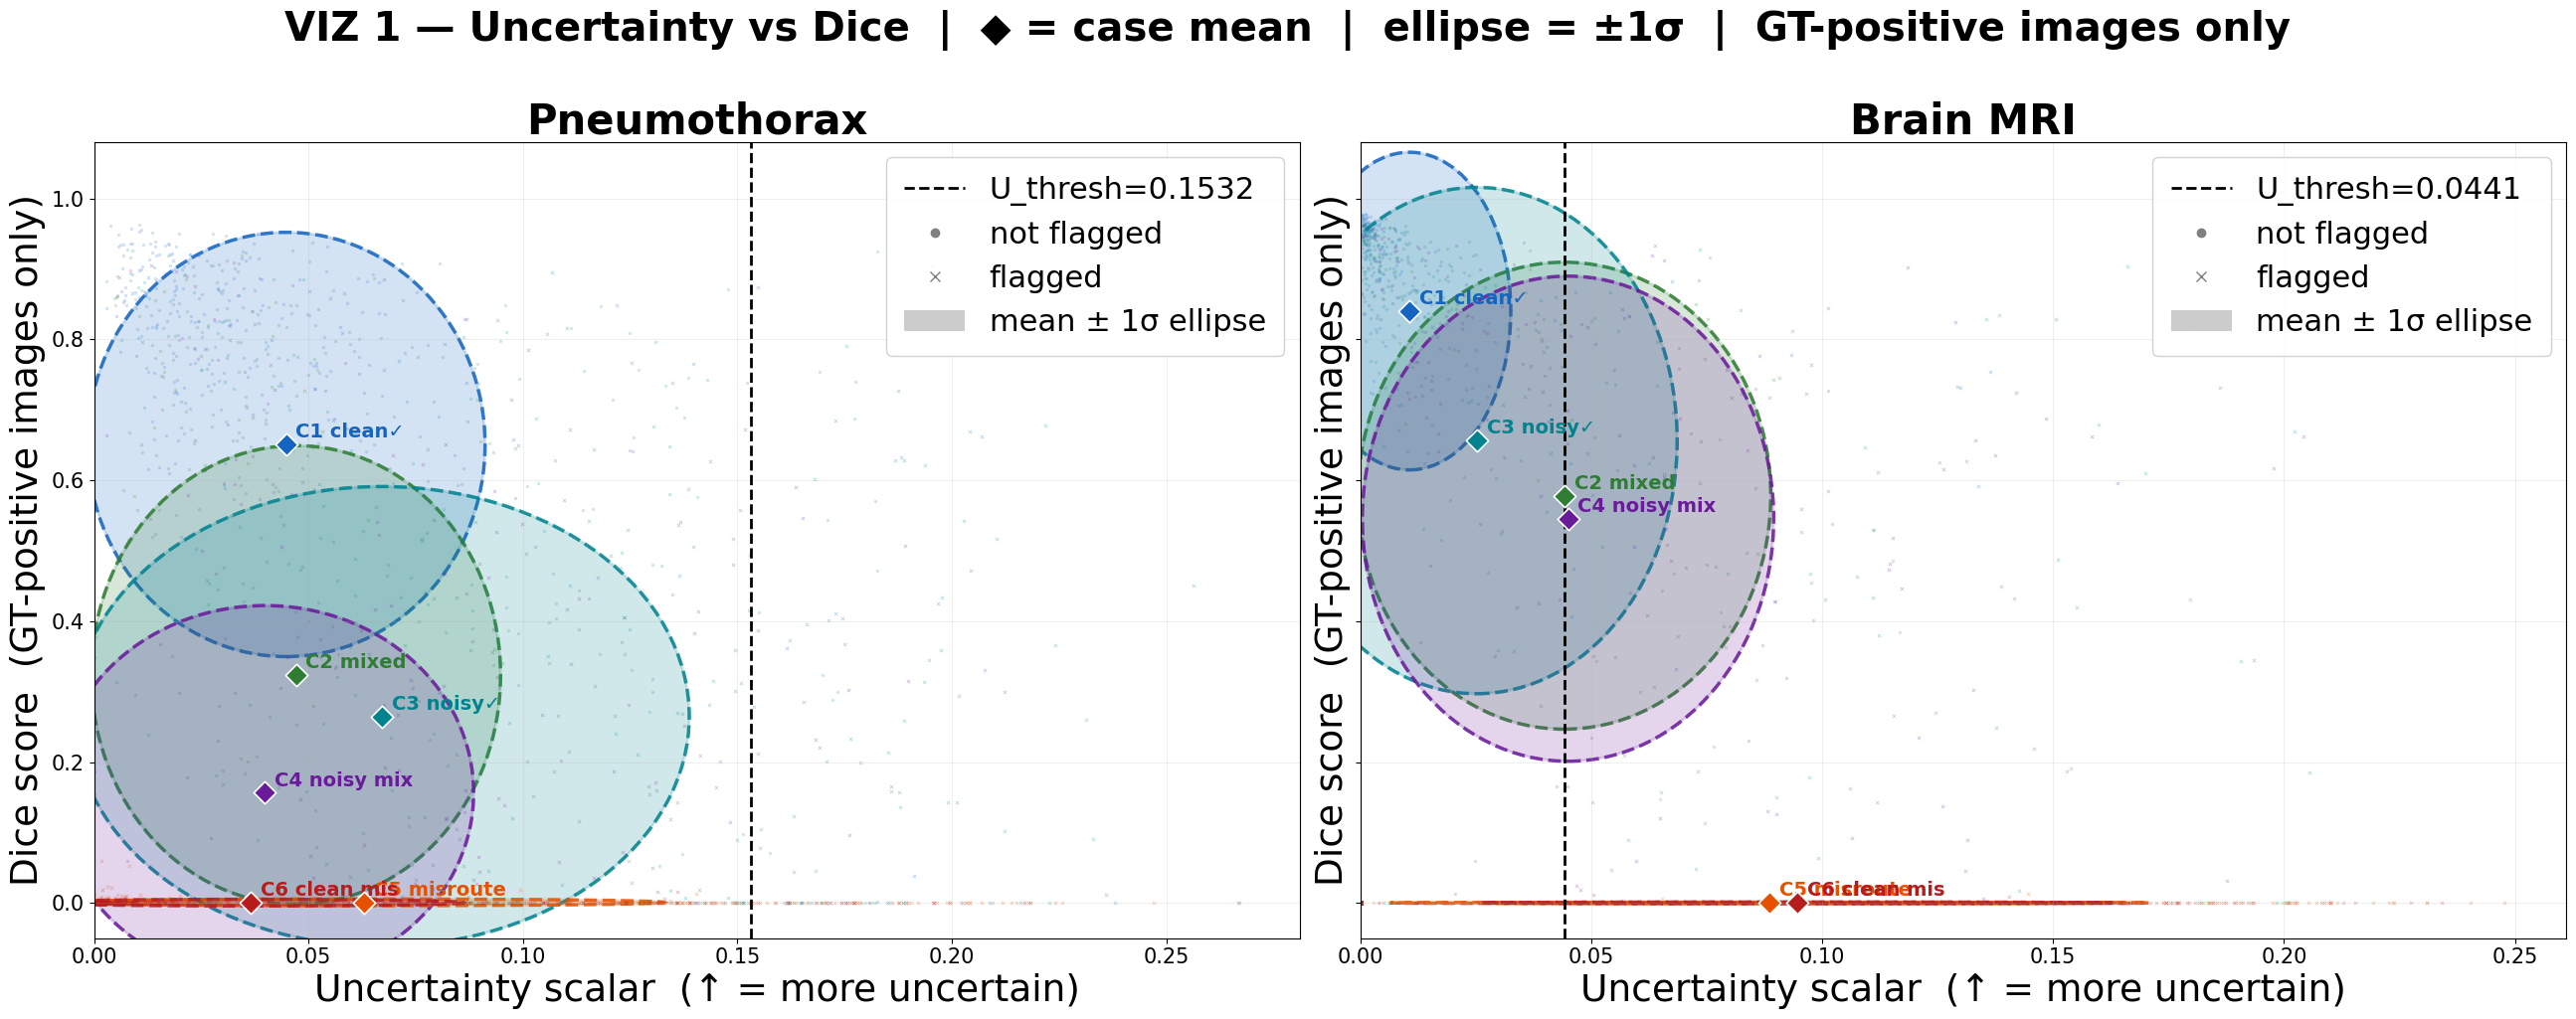

Saved → viz1_uncertainty_vs_dice.png


In [18]:
# ============================================================
# VIZ 1 — UNCERTAINTY vs DICE SCATTER
# Per-image dots (GT-positive only, tiny) + per-case summary ellipses.
# Color  : unique per case  (CASE_STYLE colors)
# Marker : circle = not flagged | cross = flagged
# Ellipse: centre = (mean_unc, mean_Dice), axes = ±1 std
# ============================================================
from matplotlib.patches import Ellipse

CASE_STYLE = {
    "1  Sᴼ clean correct":  ("C1 clean✓",    "#1565C0"),
    "2  Sᴴ clean mixed":    ("C2 mixed",      "#2E7D32"),
    "3  Sᴼ noisy correct":  ("C3 noisy✓",    "#00838F"),
    "4  Sᴴ noisy mixed":    ("C4 noisy mix",  "#6A1B9A"),
    "5  Sᴼ(abl) misroute":  ("C5 misroute",   "#E65100"),
    "6  Sᴼ clean misroute": ("C6 clean mis",  "#B71C1C"),
}

fig, axes = plt.subplots(1, 2, figsize=(26, 10), sharey=True)

for ax, (domain_label, dfs, u_key) in zip(
    axes,
    [("Pneumothorax", pneumo_dfs, "pneumo"),
     ("Brain MRI",    brain_dfs,  "brain")],
):
    for lbl, df in dfs.items():
        short, col = CASE_STYLE[lbl]

        # GT-positive only — excludes fake Dice=1.0 from empty-mask TNs
        pos = df[df["gt_positive"] == 1]
        if len(pos) == 0:
            continue

        nf = pos[pos["flag"] == False]
        fl = pos[pos["flag"] == True]

        # tiny individual dots — background context
        ax.scatter(nf["unc_scalar"], nf["dice_raw"],
                   s=6, alpha=0.18, color=col, marker="o", linewidths=0)
        ax.scatter(fl["unc_scalar"], fl["dice_raw"],
                   s=6, alpha=0.35, color=col, marker="x", linewidths=0.5)

        # ── summary ellipse (mean ± 1σ) ────────────────────────────────
        mu_u  = pos["unc_scalar"].mean();  sd_u  = pos["unc_scalar"].std()
        mu_d  = pos["dice_raw"].mean();    sd_d  = pos["dice_raw"].std()
        ell = Ellipse((mu_u, mu_d), width=2*sd_u, height=2*sd_d,
                      edgecolor=col, facecolor=col, alpha=0.18, linewidth=2)
        ax.add_patch(ell)
        ell2 = Ellipse((mu_u, mu_d), width=2*sd_u, height=2*sd_d,
                       edgecolor=col, facecolor="none", alpha=0.85, linewidth=2.5,
                       linestyle="--")
        ax.add_patch(ell2)
        ax.scatter(mu_u, mu_d, s=130, color=col, marker="D",
                   edgecolors="white", linewidths=1.2, zorder=6, label=short)
        ax.annotate(short, (mu_u, mu_d),
                    textcoords="offset points", xytext=(7, 5),
                    fontsize=14, color=col, fontweight="bold")

    # threshold line
    u_thr = U_THRESH[u_key]
    ax.axvline(u_thr, color="black", linestyle="--", linewidth=2,
               label=f"U_thresh={u_thr:.4f}")

    ax.set_xlabel("Uncertainty scalar  (↑ = more uncertain)", fontsize=27)
    ax.set_ylabel("Dice score  (GT-positive images only)", fontsize=27)
    ax.set_title(f"{domain_label}", fontsize=30, fontweight="bold")
    ax.set_xlim(left=0)
    ax.set_ylim(-0.05, 1.08)
    ax.grid(True, alpha=0.2)
    ax.tick_params(labelsize=15)

    import matplotlib.lines as mlines
    import matplotlib.patches as mpatches
    thr_line  = mlines.Line2D([], [], color="black", linestyle="--", linewidth=2,
                              label=f"U_thresh={u_thr:.4f}")
    dot_nf    = mlines.Line2D([], [], color="grey", marker="o", linestyle="None",
                              markersize=6, label="not flagged")
    dot_fl    = mlines.Line2D([], [], color="grey", marker="x", linestyle="None",
                              markersize=7, label="flagged")
    ell_patch = mpatches.Patch(facecolor="grey", alpha=0.4, label="mean ± 1σ ellipse")
    ax.legend(handles=[thr_line, dot_nf, dot_fl, ell_patch],
              fontsize=22, loc="upper right", framealpha=0.88,
              borderpad=0.6, labelspacing=0.5)

plt.suptitle(
    "VIZ 1 — Uncertainty vs Dice  |  ◆ = case mean  |  ellipse = ±1σ  "
    "|  GT-positive images only",
    fontsize=29, y=1.02, fontweight="bold")
plt.tight_layout()
plt.savefig("viz1_uncertainty_vs_dice.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → viz1_uncertainty_vs_dice.png")

Saved → viz2a_uncertainty_lung.png


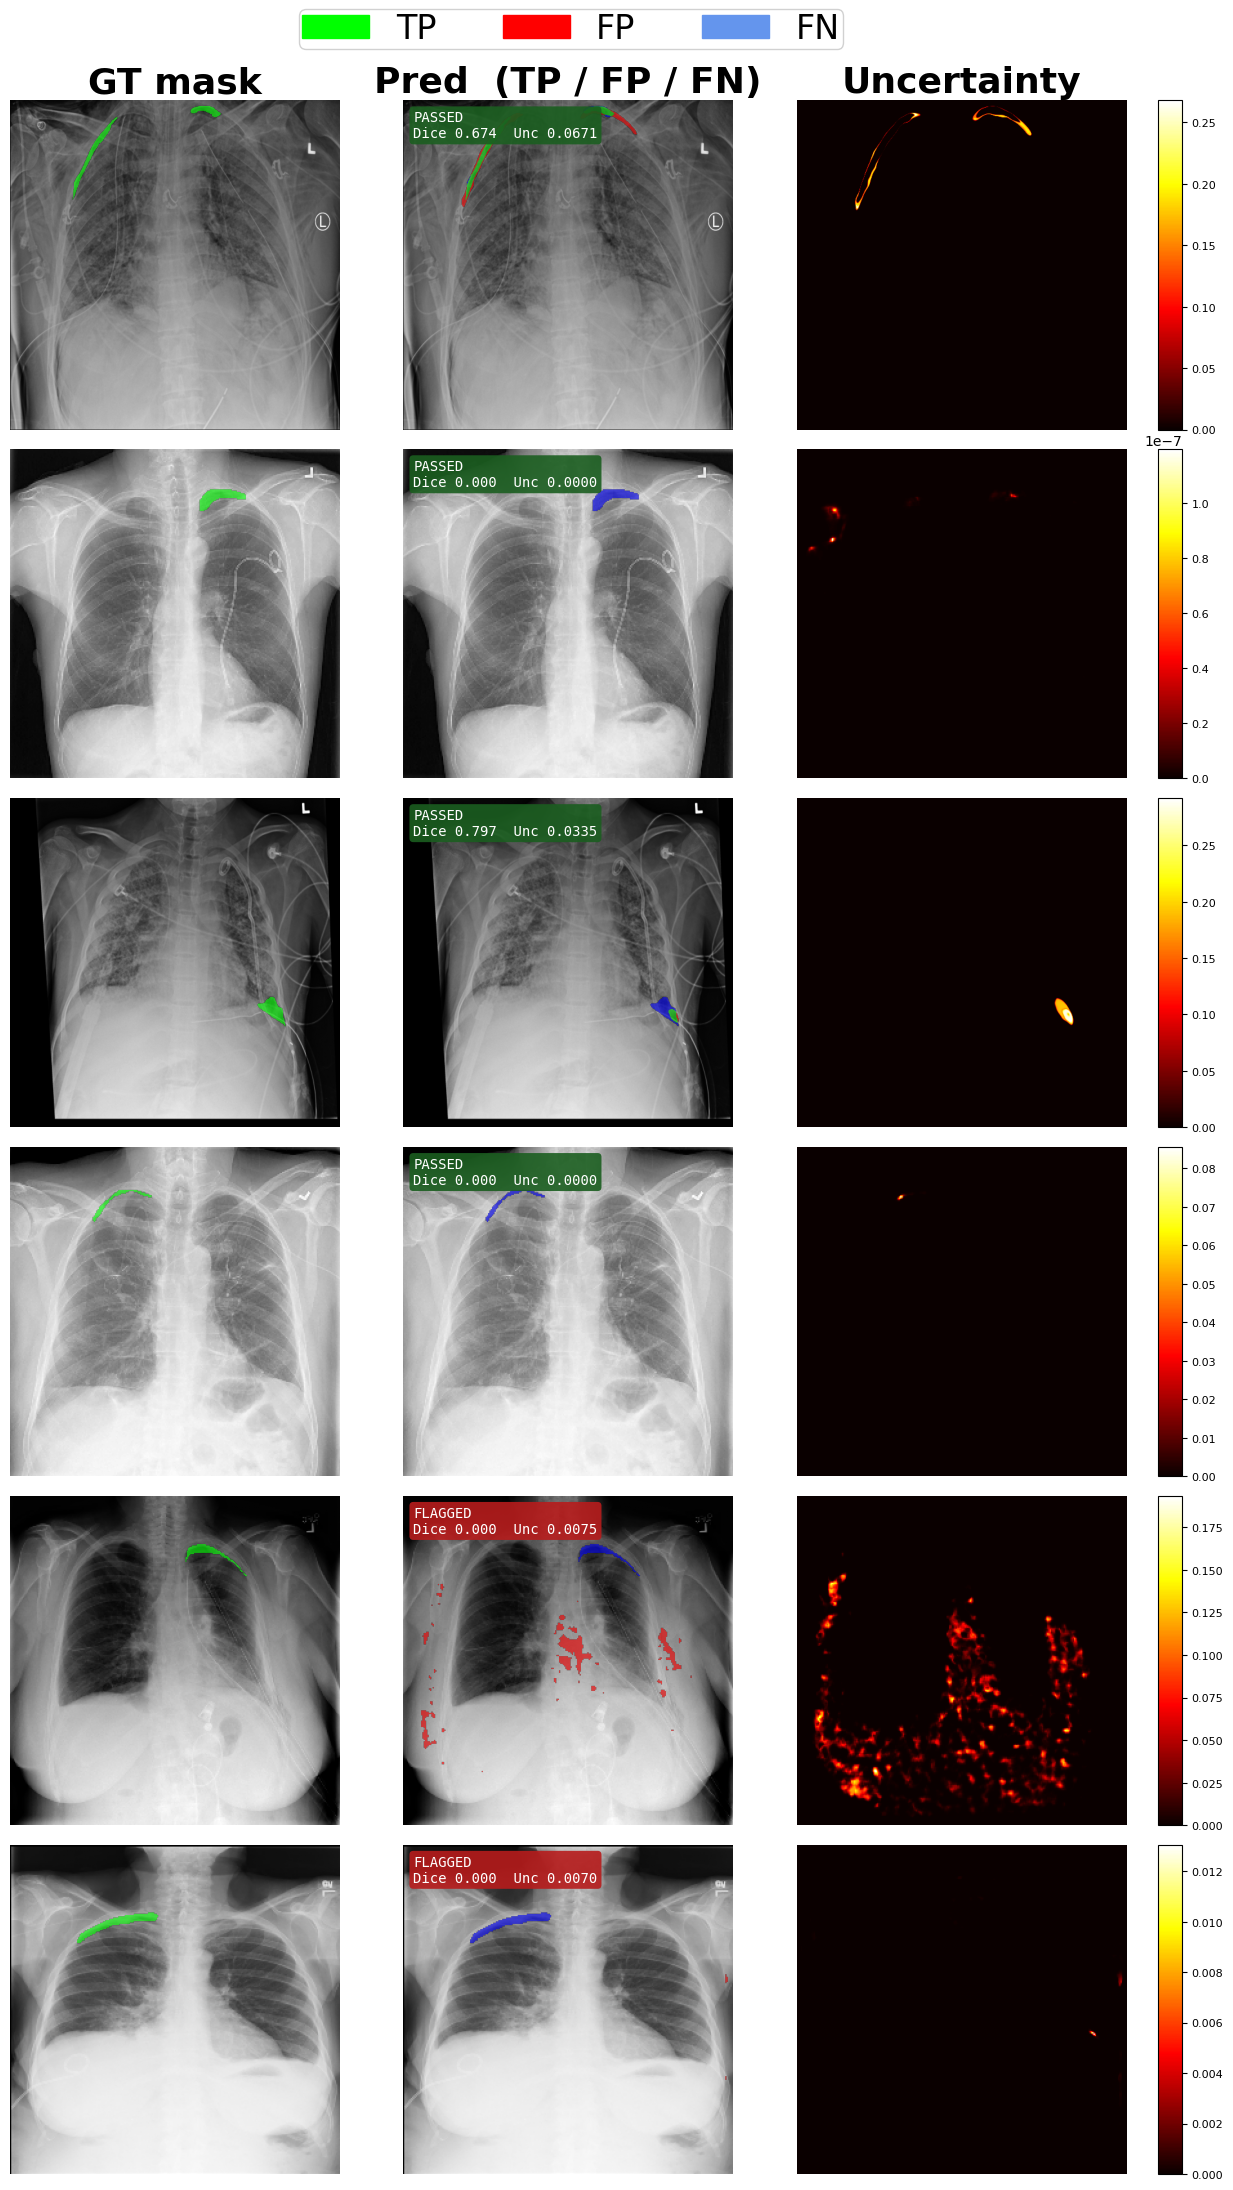

Saved → viz2b_uncertainty_brain.png


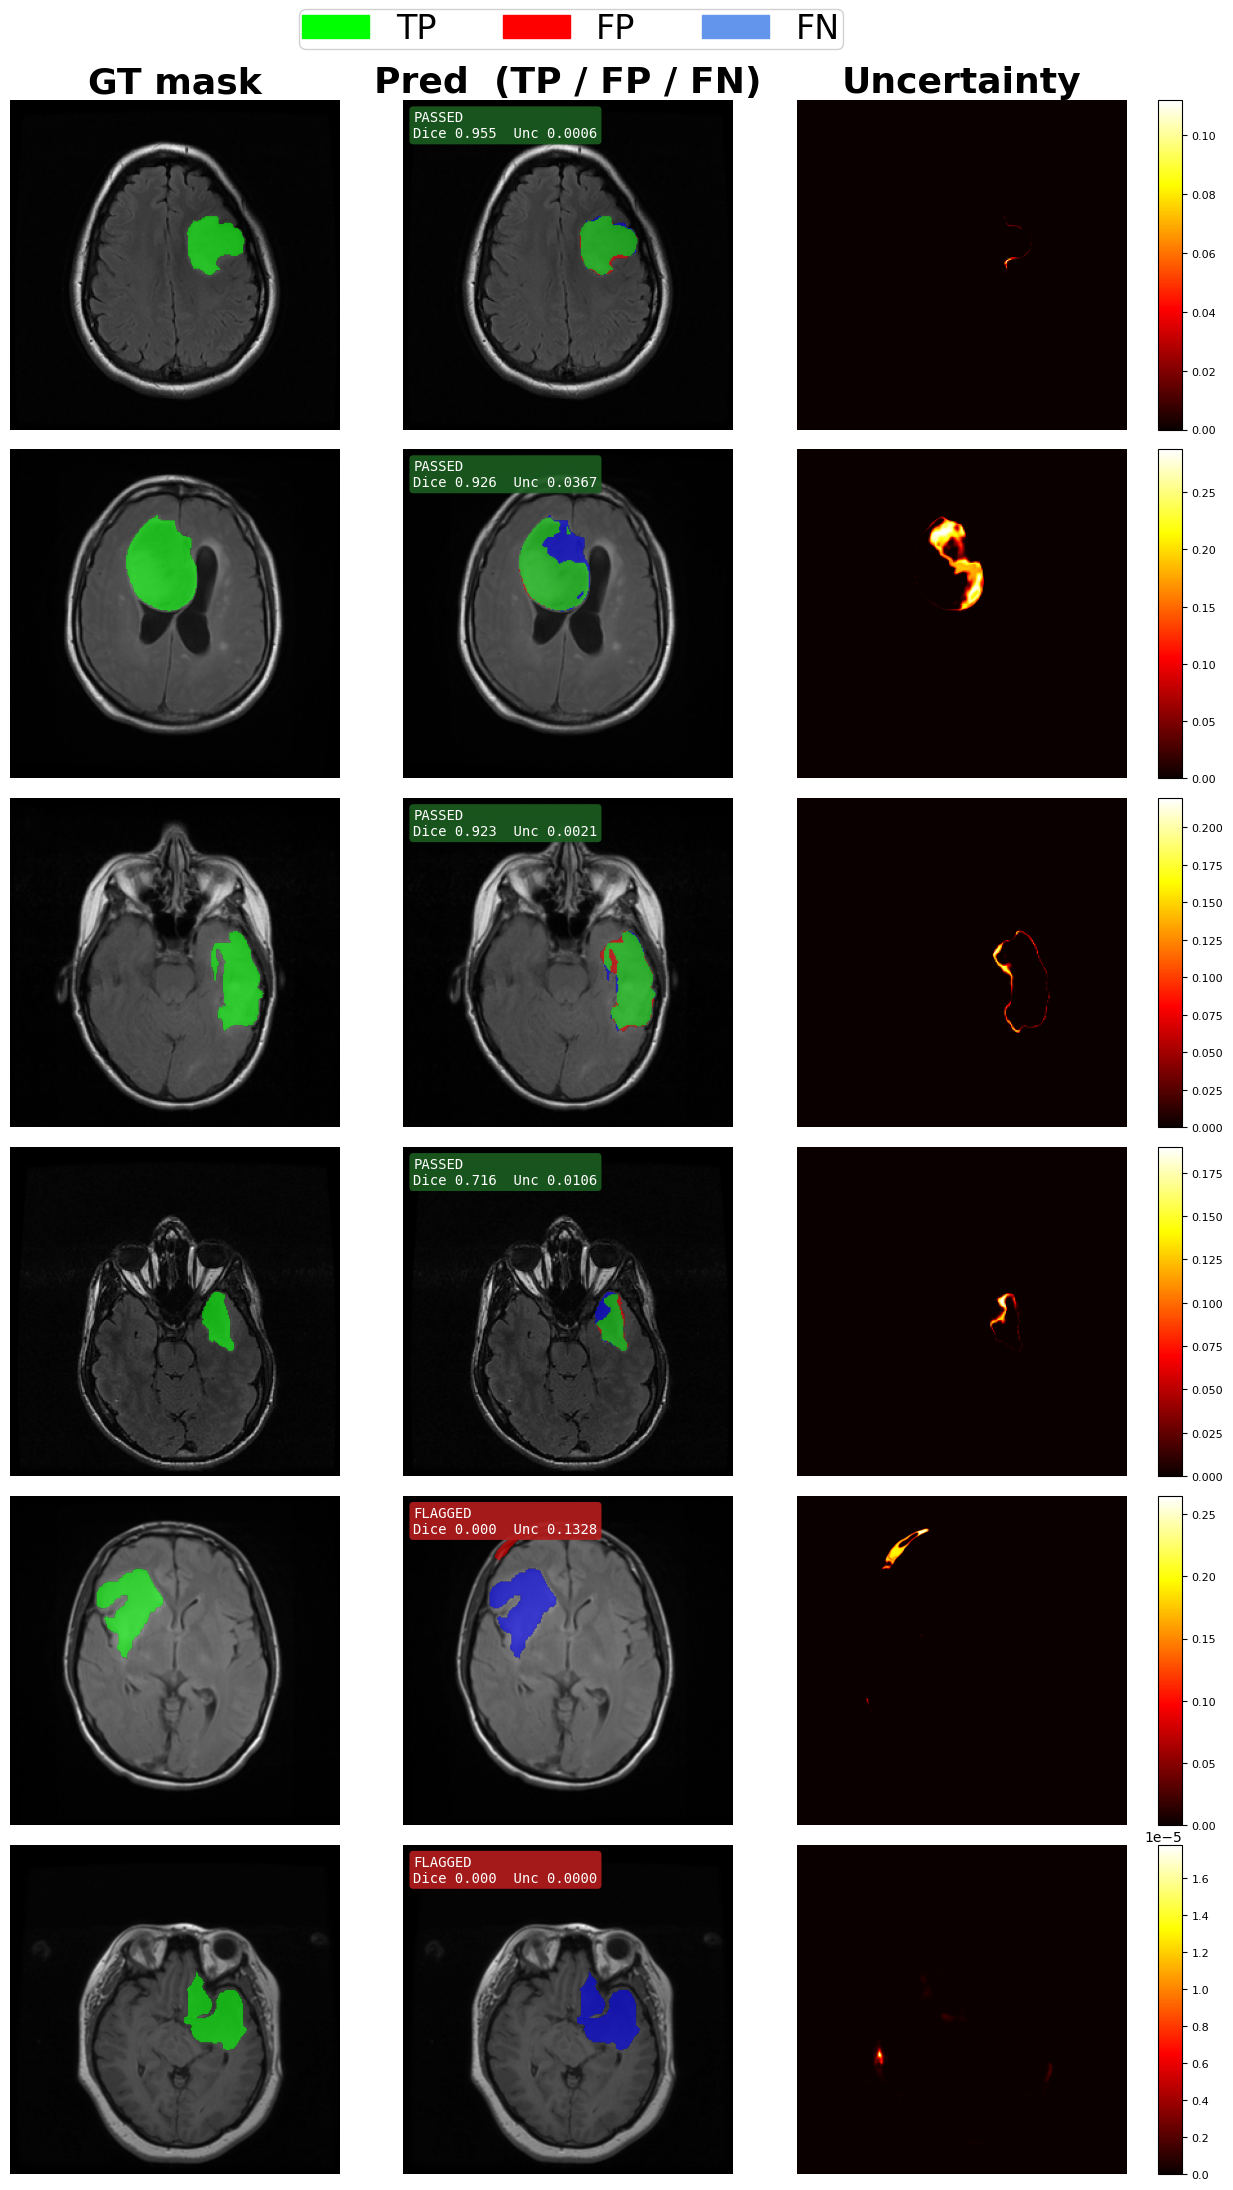

In [19]:
# ============================================================
# VIZ 2 — PER-PIXEL UNCERTAINTY MAPS
# Two separate figures: Lung domain (6 cases) | Brain domain (6 cases)
# 6 rows (C1–C6), 3 cols: GT mask | Pred (TP/FP/FN) | Uncertainty
# ============================================================
import matplotlib.patches as mpatches

# ── helpers (also used by VIZ 3) ──────────────────────────────────────────
@torch.no_grad()
def mc_dropout_spatial(model, img_tensor, n_mc=N_MC, device=DEVICE):
    x = img_tensor.unsqueeze(0).to(device)
    _enable_mc_dropout(model)
    probs = [torch.sigmoid(model(x)) for _ in range(n_mc)]
    model.eval()
    stacked   = torch.stack(probs, dim=0)
    mean_prob = stacked.mean(0)[0, 0].cpu().numpy()
    pixel_var = stacked.var(0)[0, 0].cpu().numpy()
    return mean_prob, pixel_var, mean_prob > THRESHOLD


def load_single_image(img_path, image_size, out_channels,
                      norm_mode="zscore", noisy=False, noise_seed=42):
    gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    gray = cv2.resize(gray, (image_size, image_size))
    x    = gray.astype(np.float32)
    x    = (x / 255.0 - 0.5) / 0.5 if norm_mode == "norm05" \
           else (x - x.mean()) / (x.std() + 1e-6)
    if noisy:
        rng_n = np.random.default_rng(noise_seed)
        x    += rng_n.standard_normal(x.shape).astype(np.float32) * \
                float(rng_n.uniform(NOISE_STD_MIN, NOISE_STD_MAX))
    ch_ax = x[:, :, np.newaxis] if out_channels == 1 \
            else np.stack([x, x, x], axis=-1)
    dummy = np.zeros((image_size, image_size, 1), dtype=np.float32)
    out   = get_clean_transform()(image=ch_ax, mask=dummy)
    return out["image"], gray


def load_single_mask(mask_path, image_size, mask_threshold):
    m = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if m is None:
        return np.zeros((image_size, image_size), dtype=np.float32)
    m = _max_pool_downsample_mask(m, image_size)
    return (m > mask_threshold).astype(np.float32)


def _pick_ex(df, pairs, want_flagged, seed):
    """Pick one example image from df. Returns (df_idx, img_path, msk_path)."""
    rng2 = np.random.default_rng(seed)
    sub  = df[(df["flag"] == want_flagged) & (df["gt_positive"] == 1)]
    if len(sub) == 0:
        sub = df[df["gt_positive"] == 1]
    if len(sub) == 0:
        sub = df
    row    = sub.iloc[int(rng2.integers(len(sub)))]
    df_idx = row.name
    img_p  = row["img_path"]
    msk_p  = row["msk_path"]
    return df_idx, img_p, msk_p


# ── case spec tables ────────────────────────────────────────────────────────
_LUNG_SPEC = [
    ("1  S\u1d3c clean correct",  "C1\nclean ",      pneumo_model, pneumo_sz, pneumo_meta["in_channels"], pneumo_meta["norm_mode"], False, "pneumo",      False),
    ("2  S\u1d34 clean mixed",    "C2\nmixed",              mixed_model,  mixed_sz,  mixed_meta["in_channels"],  mixed_meta["norm_mode"],  False, "mixed_lung",  False),
    ("3  S\u1d3c noisy correct",  "C3\nnoisy ",       pneumo_model, pneumo_sz, pneumo_meta["in_channels"], pneumo_meta["norm_mode"], True,  "pneumo",      False),
    ("4  S\u1d34 noisy mixed",    "C4\nnoisy mix",          mixed_model,  mixed_sz,  mixed_meta["in_channels"],  mixed_meta["norm_mode"],  True,  "mixed_lung",  False),
    ("5  S\u1d3c(abl) misroute",  "C5\nmisroute \u2717",    brain_model,  brain_sz,  brain_meta["in_channels"],  brain_meta["norm_mode"],  True,  "brain",       True),
    ("6  S\u1d3c clean misroute", "C6\nc.misroute \u2717",  brain_model,  brain_sz,  brain_meta["in_channels"],  brain_meta["norm_mode"],  False, "brain",       True),
]

_BRAIN_SPEC = [
    ("1  S\u1d3c clean correct",  "C1\nclean ",      brain_model,  brain_sz,  brain_meta["in_channels"],  brain_meta["norm_mode"],  False, "brain",       False),
    ("2  S\u1d34 clean mixed",    "C2\nmixed",              mixed_model,  mixed_sz,  mixed_meta["in_channels"],  mixed_meta["norm_mode"],  False, "mixed_brain", False),
    ("3  S\u1d3c noisy correct",  "C3\nnoisy ",       brain_model,  brain_sz,  brain_meta["in_channels"],  brain_meta["norm_mode"],  True,  "brain",       False),
    ("4  S\u1d34 noisy mixed",    "C4\nnoisy mix",          mixed_model,  mixed_sz,  mixed_meta["in_channels"],  mixed_meta["norm_mode"],  True,  "mixed_brain", False),
    ("5  S\u1d3c(abl) misroute",  "C5\nmisroute \u2717",    pneumo_model, pneumo_sz, pneumo_meta["in_channels"], pneumo_meta["norm_mode"], True,  "pneumo",      True),
    ("6  S\u1d3c clean misroute", "C6\nc.misroute \u2717",  pneumo_model, pneumo_sz, pneumo_meta["in_channels"], pneumo_meta["norm_mode"], False, "pneumo",      True),
]


def _render_unc_maps(spec_list, dfs, pairs, mask_thr, domain_title, save_path):
    """
    6-row x 3-col uncertainty-map figure.
    Uses a 4-column GridSpec: col 0=GT, col 1=Pred, col 2=Unc image,
    col 3=dedicated colorbar strip — keeps image cols perfectly flush.
    TP/FP/FN legend is placed in figure space (above images) so it is
    never obscured by imshow content.
    """
    import matplotlib.gridspec as mgridspec
    n = len(spec_list)

    fig = plt.figure(figsize=(14, 3.6 * n))
    gs  = mgridspec.GridSpec(
        n, 4,
        width_ratios=[1, 1, 1, 0.06],
        wspace=0.0, hspace=0.06,
        left=0.13, right=0.99, top=0.97, bottom=0.01,
    )

    seed_base = 0 if pairs is lung_test_pairs else 50

    for row_i, (df_key, row_lbl, model, sz, ch, norm, noisy, u_key, want_flag) \
            in enumerate(spec_list):
        seed = seed_base + row_i
        idx, img_p, msk_p = _pick_ex(dfs[df_key], pairs, want_flag, seed)

        img_t, gray = load_single_image(img_p, sz, ch, norm,
                                        noisy=noisy, noise_seed=seed)
        gt_mask = load_single_mask(msk_p, sz, mask_thr)
        _, px_var, pred_bin = mc_dropout_spatial(model, img_t)
        disp = (gray - gray.min()) / (gray.max() - gray.min() + 1e-6)

        ax0   = fig.add_subplot(gs[row_i, 0])
        ax1   = fig.add_subplot(gs[row_i, 1])
        ax2   = fig.add_subplot(gs[row_i, 2])
        ax_cb = fig.add_subplot(gs[row_i, 3])

        # col 0 — GT overlay
        gt_rgba = np.zeros((*disp.shape, 4))
        gt_rgba[..., 1] = gt_mask;  gt_rgba[..., 3] = gt_mask * 0.6
        ax0.imshow(disp, cmap="gray", vmin=0, vmax=1)
        ax0.imshow(gt_rgba)

        # col 1 — TP/FP/FN + flag badge
        tp = pred_bin & (gt_mask > 0)
        fp = pred_bin & ~(gt_mask > 0)
        fn = ~pred_bin & (gt_mask > 0)
        pr = np.zeros((*disp.shape, 4))
        pr[tp, 1] = 0.9;  pr[tp, 3] = 0.55
        pr[fp, 0] = 0.9;  pr[fp, 3] = 0.65
        pr[fn, 2] = 0.9;  pr[fn, 3] = 0.65
        ax1.imshow(disp, cmap="gray", vmin=0, vmax=1)
        ax1.imshow(pr)
        try:
            r    = dfs[df_key].loc[idx]
            flag = bool(r["flag"])
            bc   = "#b71c1c" if flag else "#1b5e20"
            ax1.text(0.03, 0.97,
                     f"{'FLAGGED' if flag else 'PASSED'}\n"
                     f"Dice {float(r['dice_raw']):.3f}  Unc {float(r['unc_scalar']):.4f}",
                     transform=ax1.transAxes, fontsize=10, va="top",
                     family="monospace", color="white", zorder=10,
                     bbox=dict(boxstyle="round,pad=0.28", facecolor=bc,
                               alpha=0.9, edgecolor="none", zorder=10))
        except Exception:
            pass

        # col 2 — uncertainty heat-map
        im = ax2.imshow(px_var, cmap="hot", vmin=0,
                        vmax=max(float(px_var.max()), 1e-8))
        plt.colorbar(im, cax=ax_cb)
        ax_cb.tick_params(labelsize=8)

        for ax_ in [ax0, ax1, ax2]:
            ax_.axis("off")
        ax0.set_ylabel(row_lbl, fontsize=24, rotation=0,
                       labelpad=72, va="center", fontweight="bold")

        if row_i == 0:
            ax0.set_title("GT mask",               fontsize=26, fontweight="bold")
            ax1.set_title("Pred  (TP / FP / FN)",  fontsize=26, fontweight="bold")
            ax2.set_title("Uncertainty",            fontsize=26, fontweight="bold")

    # TP/FP/FN legend placed in figure coordinates — never behind an image
    pats = [mpatches.Patch(color="lime",           label="TP"),
            mpatches.Patch(color="red",            label="FP"),
            mpatches.Patch(color="cornflowerblue", label="FN")]
    fig.legend(handles=pats, fontsize=24, loc="upper right",
               bbox_to_anchor=(0.76, 1.02),
               framealpha=0.9, borderpad=0.1, ncol=3)
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"Saved \u2192 {save_path}")
    plt.show()


# ── render both domains ────────────────────────────────────────────────────
_render_unc_maps(_LUNG_SPEC,  pneumo_dfs, lung_test_pairs,  127,
                 "Pneumothorax / Lung",
                 "viz2a_uncertainty_lung.png")

_render_unc_maps(_BRAIN_SPEC, brain_dfs,  brain_test_pairs, 0,
                 "Brain MRI",
                 "viz2b_uncertainty_brain.png")

Saved → viz3a_gallery_lung.png


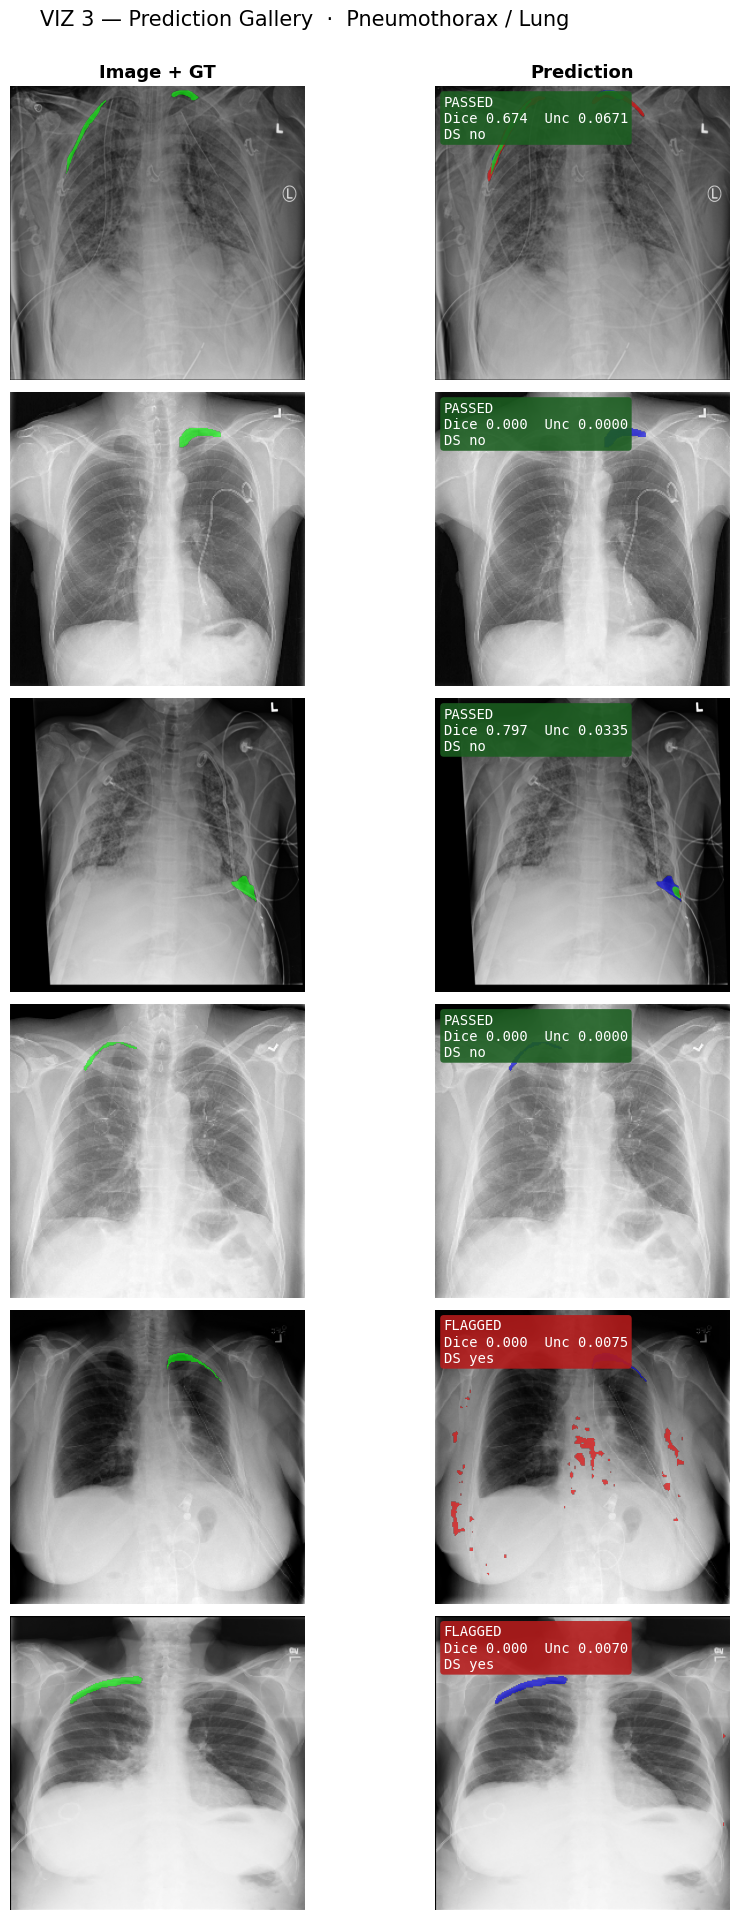

Saved → viz3b_gallery_brain.png


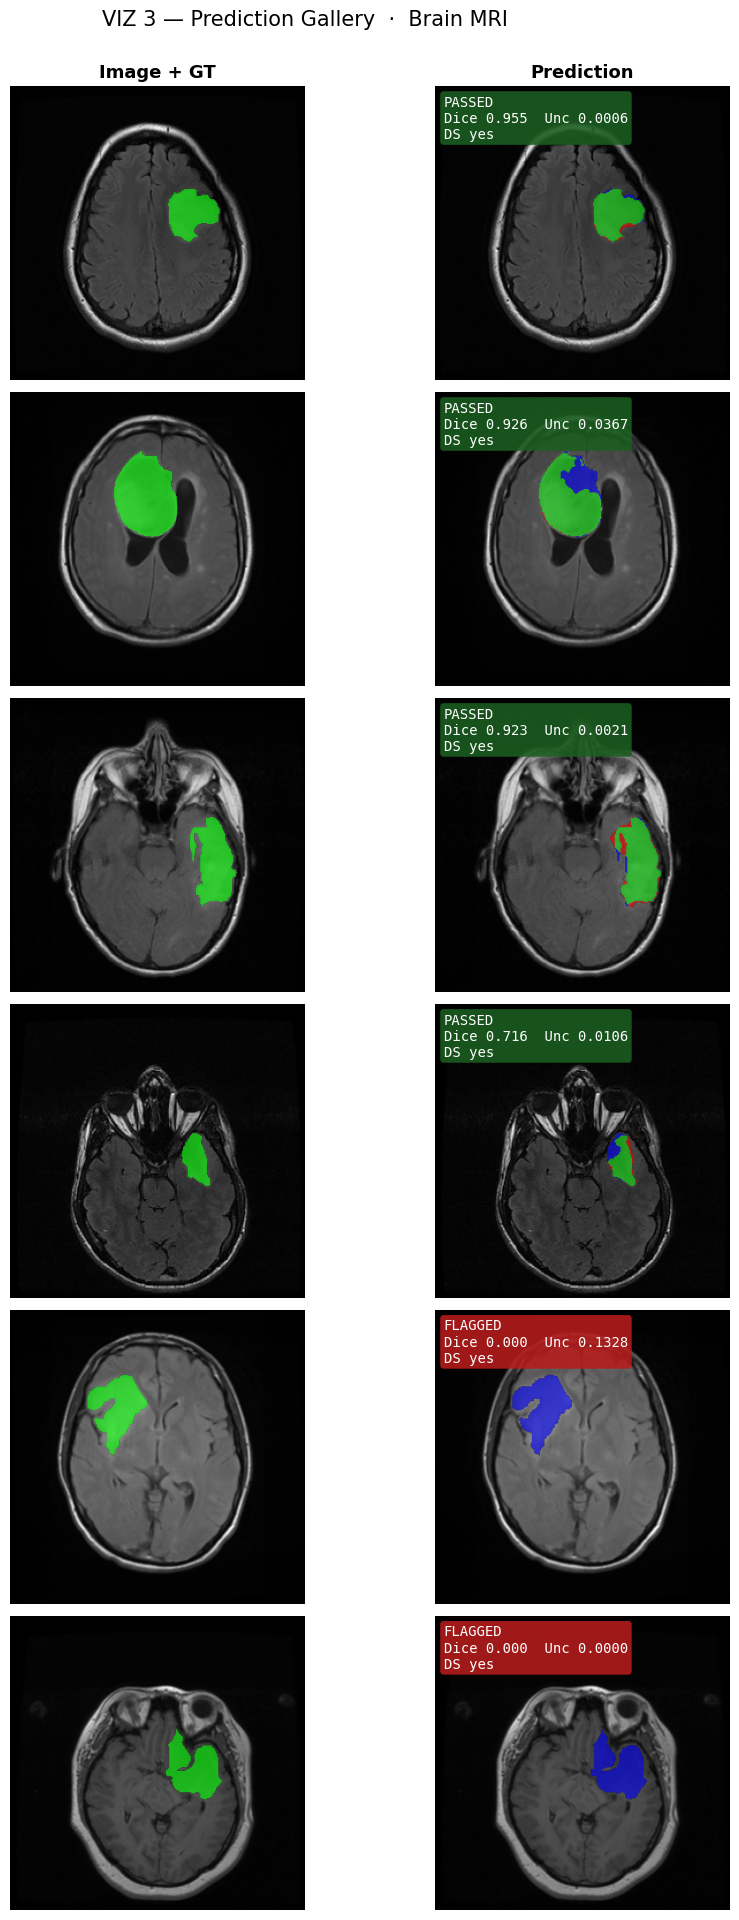

In [20]:
# ============================================================
# VIZ 3 — PREDICTION GALLERY
# Two separate figures: Lung domain (6 cases) | Brain domain (6 cases)
# 6 rows (C1–C6), 2 cols: Image + GT overlay | Prediction + badge
# ============================================================

def _render_gallery(spec_list, dfs, pairs, mask_thr, domain_title, save_path):
    """6-row x 2-col compact gallery figure, saved to disk."""
    n   = len(spec_list)
    fig = plt.figure(figsize=(10, 3.2 * n))
    gs  = fig.add_gridspec(n, 2, wspace=0.0, hspace=0.04,
                           left=0.14, right=0.99, top=0.96, bottom=0.01)

    seed_base = 0 if pairs is lung_test_pairs else 50

    for row_i, (df_key, row_lbl, model, sz, ch, norm, noisy, u_key, want_flag) \
            in enumerate(spec_list):
        seed = seed_base + row_i
        idx, img_p, msk_p = _pick_ex(dfs[df_key], pairs, want_flag, seed)

        img_t, gray = load_single_image(img_p, sz, ch, norm,
                                        noisy=noisy, noise_seed=seed)
        gt_mask = load_single_mask(msk_p, sz, mask_thr)
        pred_mean, _, pred_bin = mc_dropout_spatial(model, img_t)

        disp = (gray - gray.min()) / (gray.max() - gray.min() + 1e-6)

        # col 0 — image + GT overlay
        ax0 = fig.add_subplot(gs[row_i, 0])
        gt_rgba = np.zeros((*disp.shape, 4))
        gt_rgba[..., 1] = gt_mask;  gt_rgba[..., 3] = gt_mask * 0.6
        ax0.imshow(disp, cmap="gray", vmin=0, vmax=1)
        ax0.imshow(gt_rgba)
        ax0.axis("off")
        ax0.set_ylabel(row_lbl, fontsize=13, rotation=0,
                       labelpad=64, va="center", fontweight="bold")
        if row_i == 0:
            ax0.set_title("Image + GT", fontsize=13, fontweight="bold")

        # col 1 — prediction + badge
        ax1 = fig.add_subplot(gs[row_i, 1])
        tp = pred_bin & (gt_mask > 0)
        fp = pred_bin & ~(gt_mask > 0)
        fn = ~pred_bin & (gt_mask > 0)
        pr = np.zeros((*disp.shape, 4))
        pr[tp, 1] = 0.9;  pr[tp, 3] = 0.55
        pr[fp, 0] = 0.9;  pr[fp, 3] = 0.65
        pr[fn, 2] = 0.9;  pr[fn, 3] = 0.65
        ax1.imshow(disp, cmap="gray", vmin=0, vmax=1)
        ax1.imshow(pr)
        ax1.axis("off")
        if row_i == 0:
            ax1.set_title("Prediction", fontsize=13, fontweight="bold")

        # badge on prediction panel
        try:
            r    = dfs[df_key].loc[idx]
            flag = bool(r["flag"])
            bc   = "#b71c1c" if flag else "#1b5e20"
            dice = float(r["dice_raw"])
            unc  = float(r["unc_scalar"])
            ds   = bool(r["ds_flag"])
            badge = (f"{'FLAGGED' if flag else 'PASSED'}\n"
                     f"Dice {dice:.3f}  Unc {unc:.4f}\n"
                     f"DS {'yes' if ds else 'no'}")
            ax1.text(0.03, 0.97, badge,
                     transform=ax1.transAxes, fontsize=10, va="top",
                     family="monospace", color="white",
                     bbox=dict(boxstyle="round,pad=0.26", facecolor=bc,
                               alpha=0.88, edgecolor="none"))
        except Exception:
            pass

    fig.suptitle(f"VIZ 3 \u2014 Prediction Gallery  \u00b7  {domain_title}",
                 fontsize=15, y=1.00)
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"Saved \u2192 {save_path}")
    plt.show()


# ── render both domains ────────────────────────────────────────────────────
_render_gallery(_LUNG_SPEC,  pneumo_dfs, lung_test_pairs,  127,
                "Pneumothorax / Lung",
                "viz3a_gallery_lung.png")

_render_gallery(_BRAIN_SPEC, brain_dfs,  brain_test_pairs, 0,
                "Brain MRI",
                "viz3b_gallery_brain.png")

Saved → viz4_dice_boxplots.png


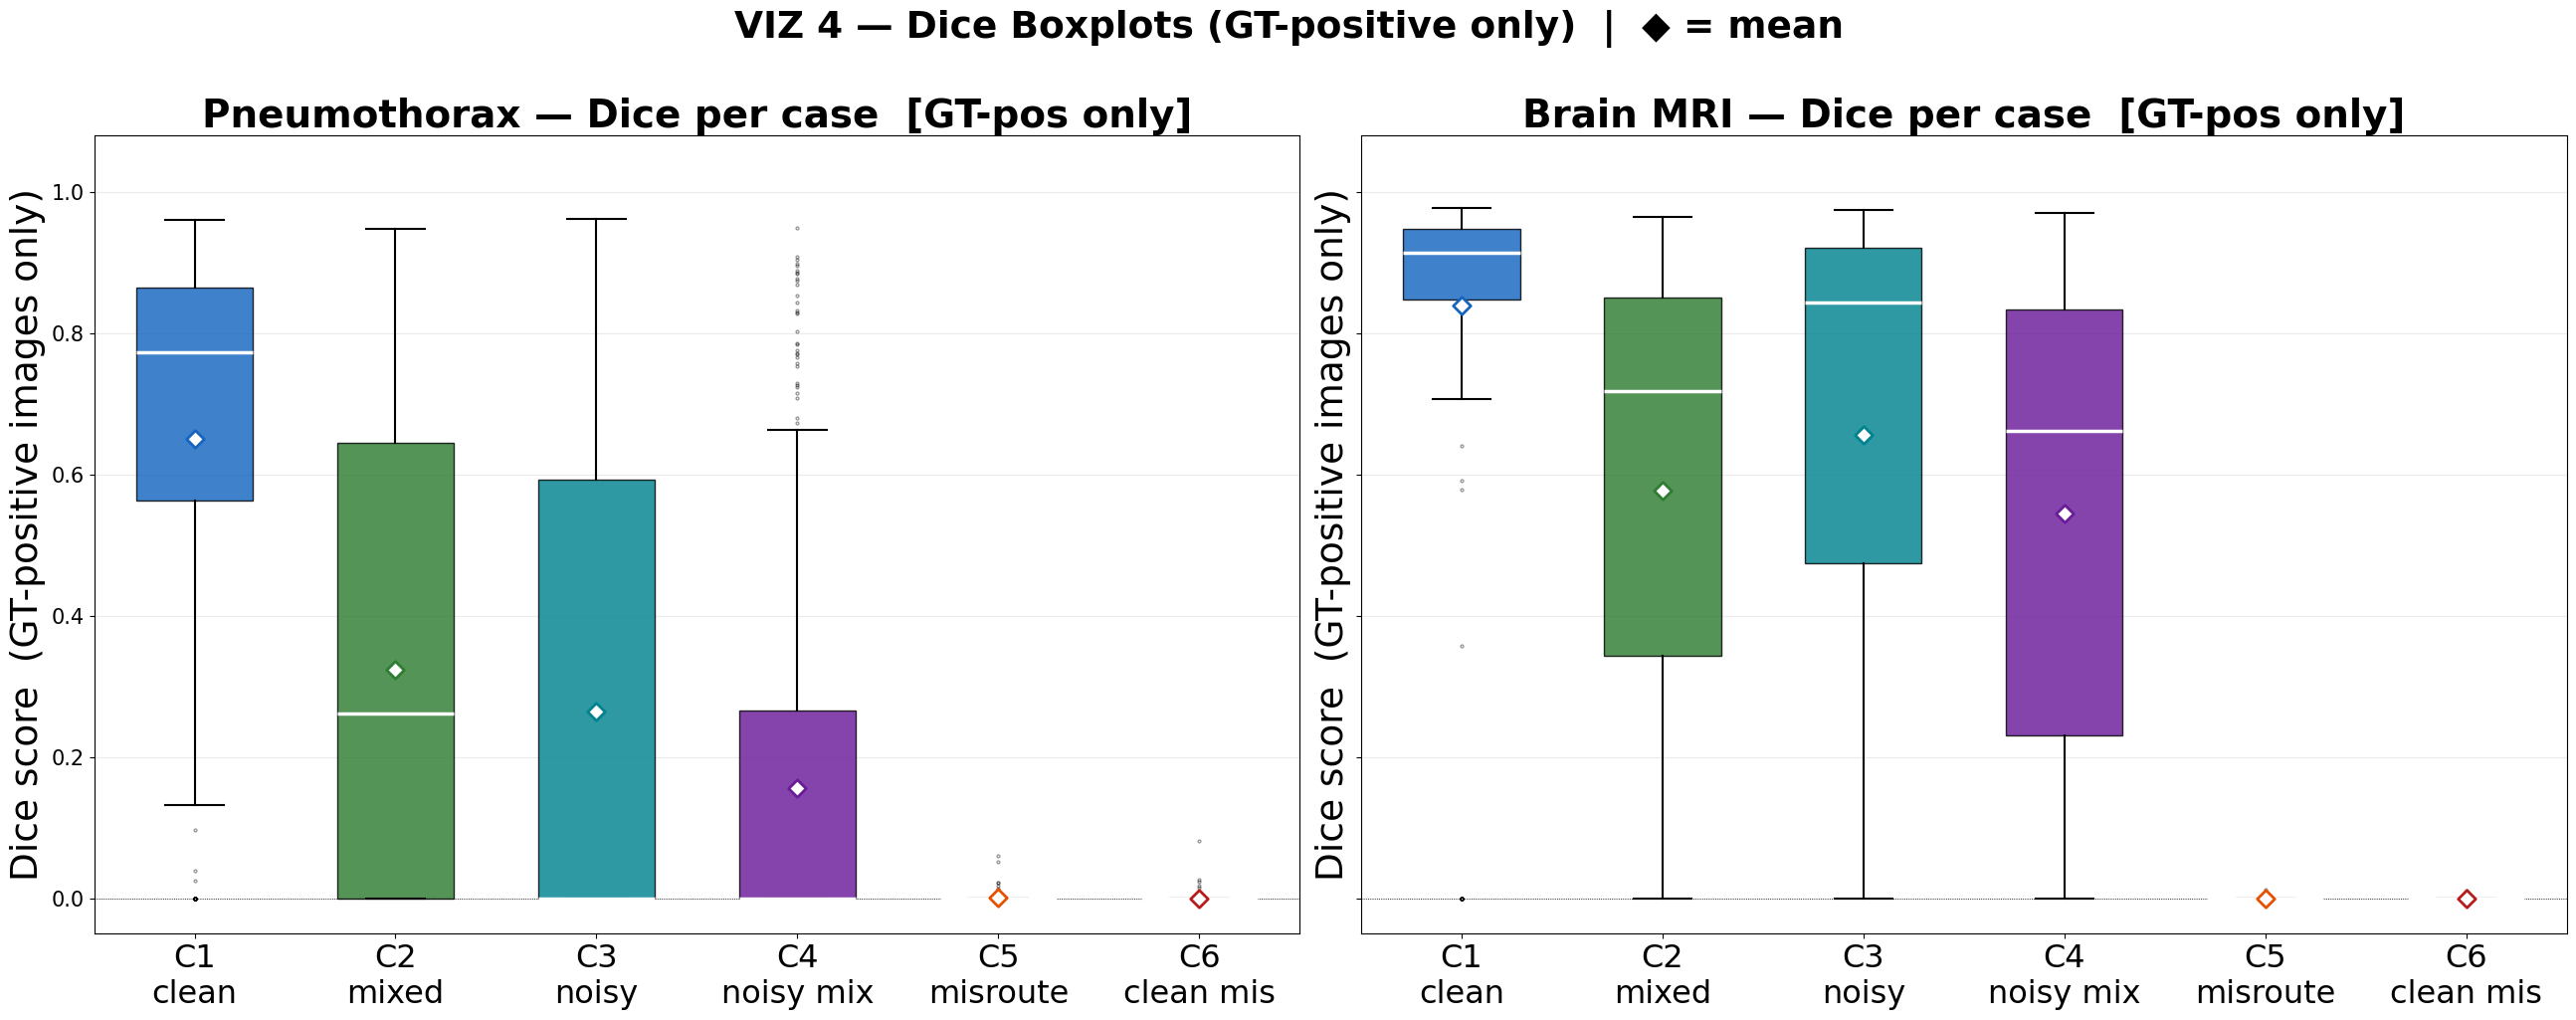

In [21]:
# ============================================================
# VIZ 4 — DICE BOXPLOTS PER CASE  (GT-positive images only)
# Filters to gt_positive==1 so TN images (Dice=1.0 by convention)
# don't inflate misroute boxes.
# Two subplots: Pneumothorax domain | Brain MRI domain.
# ============================================================

_CASE_COLORS = {
    "1  Sᴼ clean correct":  "#1565C0",
    "2  Sᴴ clean mixed":    "#2E7D32",
    "3  Sᴼ noisy correct":  "#00838F",
    "4  Sᴴ noisy mixed":    "#6A1B9A",
    "5  Sᴼ(abl) misroute":  "#E65100",
    "6  Sᴼ clean misroute": "#B71C1C",
}

_SHORT = {
    "1  Sᴼ clean correct":  "C1\nclean",
    "2  Sᴴ clean mixed":    "C2\nmixed",
    "3  Sᴼ noisy correct":  "C3\nnoisy",
    "4  Sᴴ noisy mixed":    "C4\nnoisy mix",
    "5  Sᴼ(abl) misroute":  "C5\nmisroute",
    "6  Sᴼ clean misroute": "C6\nclean mis",
}

fig, axes = plt.subplots(1, 2, figsize=(26, 10), sharey=True)

for ax, (domain_label, dfs) in zip(
    axes,
    [("Pneumothorax", pneumo_dfs), ("Brain MRI", brain_dfs)],
):
    positions = list(range(1, len(CASE_LABELS) + 1))
    data   = [dfs[lbl][dfs[lbl]["gt_positive"] == 1]["dice_raw"].values
              for lbl in CASE_LABELS]
    colors = [_CASE_COLORS[lbl] for lbl in CASE_LABELS]
    tick_lbl = [_SHORT[lbl] for lbl in CASE_LABELS]

    bp = ax.boxplot(data, positions=positions, widths=0.58,
                    patch_artist=True, notch=False,
                    medianprops=dict(color="white", linewidth=2.5),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5),
                    flierprops=dict(marker=".", markersize=4, alpha=0.4))

    for patch, col in zip(bp["boxes"], colors):
        patch.set_facecolor(col)
        patch.set_alpha(0.82)

    for pos, vals, col in zip(positions, data, colors):
        if len(vals) > 0:
            ax.scatter(pos, np.mean(vals), zorder=5, s=80,
                       marker="D", color="white", edgecolors=col, linewidths=2)

    ax.set_xticks(positions)
    ax.set_xticklabels(tick_lbl, fontsize=23)
    ax.set_ylabel("Dice score  (GT-positive images only)", fontsize=27)
    ax.set_title(f"{domain_label} — Dice per case  [GT-pos only]",
                 fontsize=28, fontweight="bold")
    ax.set_ylim(-0.05, 1.08)
    ax.grid(True, axis="y", alpha=0.25)
    ax.axhline(0, color="black", linewidth=0.6, linestyle=":")
    ax.tick_params(axis="y", labelsize=15)

plt.suptitle(
    "VIZ 4 — Dice Boxplots (GT-positive only)  |  ◆ = mean",
    fontsize=27, y=1.02, fontweight="bold")
plt.tight_layout()
plt.savefig("viz4_dice_boxplots.png", dpi=150, bbox_inches="tight")
print("Saved → viz4_dice_boxplots.png")
plt.show()

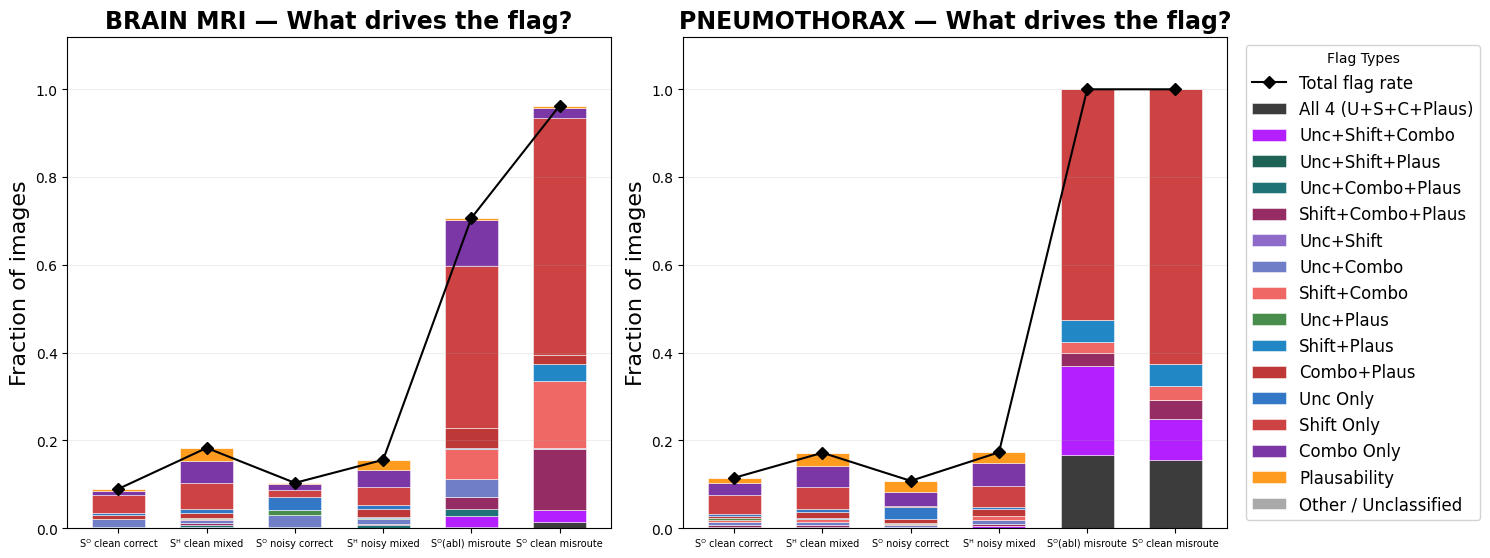

In [33]:
def decompose_flags(df: pd.DataFrame):
    """
    Decomposes the failure flags into their respective categories matching the updated scheme.
    """
    if df.empty:
        return {}

    counts = {
        "All 4 (U+S+C+Plaus)": 0,
        # 3 Flags
        "Unc+Shift+Combo": 0,
        "Unc+Shift+Plaus": 0,
        "Unc+Combo+Plaus": 0,
        "Shift+Combo+Plaus": 0,
        # 2 Flags
        "Unc+Shift": 0,
        "Unc+Combo": 0,
        "Shift+Combo": 0,
        "Unc+Plaus": 0,
        "Shift+Plaus": 0,
        "Combo+Plaus": 0,
        # 1 Flag
        "Unc Only": 0,
        "Shift Only": 0,
        "Combo Only": 0,
        "Plausability": 0,
        "Other / Unclassified": 0
    }

    # evaluate rows where at least one flag is triggered
    flagged = df[df[["geom_flag", "extreme_shift", "extreme_unc", "combo"]].any(axis=1)]

    for _, row in flagged.iterrows():
        g = bool(row.get("geom_flag", False))
        s = bool(row.get("extreme_shift", False))
        u = bool(row.get("extreme_unc", False))
        c = bool(row.get("combo", False))
        
        # 4 conditions
        if u and s and c and g:
            counts["All 4 (U+S+C+Plaus)"] += 1
            
        # 3 conditions
        elif u and s and c:
            counts["Unc+Shift+Combo"] += 1
        elif u and s and g:
            counts["Unc+Shift+Plaus"] += 1
        elif u and c and g:
            counts["Unc+Combo+Plaus"] += 1
        elif s and c and g:
            counts["Shift+Combo+Plaus"] += 1
            
        # 2 conditions
        elif u and s:
            counts["Unc+Shift"] += 1
        elif u and c:
            counts["Unc+Combo"] += 1
        elif s and c:
            counts["Shift+Combo"] += 1
        elif u and g:
            counts["Unc+Plaus"] += 1
        elif s and g:
            counts["Shift+Plaus"] += 1
        elif c and g:
            counts["Combo+Plaus"] += 1
            
        # 1 condition
        elif u:
            counts["Unc Only"] += 1
        elif s:
            counts["Shift Only"] += 1
        elif c:
            counts["Combo Only"] += 1
        elif g:
            counts["Plausability"] += 1
        else:
            counts["Other / Unclassified"] += 1

    return counts

_SIGNAL_COLORS = {
    "All 4 (U+S+C+Plaus)": "#212121",   # Very Dark Grey
    
    # 3 Flags
    "Unc+Shift+Combo": "#aa00ff",       # Bright Purple
    "Unc+Shift+Plaus": "#004D40",       # Very Dark Indigo/Teal
    "Unc+Combo+Plaus": "#006064",       # Very Dark Cyan
    "Shift+Combo+Plaus": "#880E4F",     # Very Dark Magenta
    
    # 2 Flags
    "Unc+Shift": "#7E57C2",             # Light Purple
    "Unc+Combo": "#5C6BC0",             # Light Indigo
    "Shift+Combo": "#EF5350",           # Light Red
    "Unc+Plaus": "#2E7D32",             # Green
    "Shift+Plaus": "#0277BD",           # Dark Blue
    "Combo+Plaus": "#B71C1C",           # Dark Red
    
    # 1 Flag
    "Unc Only": "#1565C0",              # Blue
    "Shift Only": "#C62828",            # Red
    "Combo Only": "#6A1B9A",            # Purple
    "Plausability": "#FF8F00",          # Orange/Amber
    
    "Other / Unclassified": "#9E9E9E"   # Grey
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, dfs, domain_label in zip(axes,
                                 [brain_dfs, pneumo_dfs],
                                 ["BRAIN MRI", "PNEUMOTHORAX"]):
    tick_lbl = [l.split(" ", 2)[-1] for l in CASE_LABELS]
    x        = np.arange(len(CASE_LABELS))

    # compute stacked values per case
    bottom = np.zeros(len(CASE_LABELS))
    for sig, col in _SIGNAL_COLORS.items():
        heights = []
        for lbl in CASE_LABELS:
            df_lbl = dfs[lbl]
            n_total = len(df_lbl)
            if n_total == 0:
                heights.append(0.0)
            else:
                counts_dict = decompose_flags(df_lbl)
                # Ensure the category names match exactly
                heights.append(counts_dict.get(sig, 0) / n_total)
                
        heights = np.array(heights)
        bars = ax.bar(x, heights, bottom=bottom, color=col, label=sig,
                      width=0.6, alpha=0.88, edgecolor="white", linewidth=0.4)
        bottom += heights

    # total flag rate as a line overlay
    total_flags = np.array([dfs[lbl]["flag"].mean() for lbl in CASE_LABELS])
    ax.plot(x, total_flags, color="black", marker="D", linewidth=1.5,
            markersize=6, label="Total flag rate", zorder=5)

    ax.set_xticks(x)
    ax.set_xticklabels(tick_lbl, fontsize=7)
    ax.set_ylabel("Fraction of images", fontsize=16)
    ax.set_title(f"{domain_label} — What drives the flag?", fontsize=17, fontweight = "bold")
    ax.set_ylim(0, 1.12)
    ax.grid(True, axis="y", alpha=0.2)
    
    # Only put legend on the second subplot to save space and put it slightly outside
    if ax == axes[1]:
        # We also want to deduplicate any duplicate 'Total flag rate' if we just do ax.legend()
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles, labels, fontsize=12, loc="upper left", framealpha=0.85, 
                  bbox_to_anchor=(1.02, 1), ncol=1, title="Flag Types")


plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.savefig("viz5_flag_breakdown.png", dpi=150)
plt.show()
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# for ax, dfs, domain_label in zip(axes,
#                                  [brain_dfs, pneumo_dfs],
#                                  ["BRAIN MRI", "PNEUMOTHORAX"]):
#     tick_lbl = [l.split(" ", 2)[-1] for l in CASE_LABELS]
#     x        = np.arange(len(CASE_LABELS))

#     # compute stacked values per case
#     bottom = np.zeros(len(CASE_LABELS))
#     for sig, col in _SIGNAL_COLORS.items():
#         heights = np.array([decompose_flags(dfs[lbl])[sig] for lbl in CASE_LABELS])
#         bars = ax.bar(x, heights, bottom=bottom, color=col, label=sig,
#                       width=0.6, alpha=0.88, edgecolor="white", linewidth=0.4)
#         bottom += heights

#     # total flag rate as a line overlay
#     total_flags = np.array([dfs[lbl]["flag"].mean() for lbl in CASE_LABELS])
#     ax.plot(x, total_flags, color="black", marker="D", linewidth=1.5,
#             markersize=6, label="Total flag rate", zorder=5)

#     ax.set_xticks(x)
#     ax.set_xticklabels(tick_lbl, fontsize=8)
#     ax.set_ylabel("Fraction of images", fontsize=11)
#     ax.set_title(f"{domain_label} — What drives the flag?", fontsize=12)
#     ax.set_ylim(0, 1.12)
#     ax.grid(True, axis="y", alpha=0.2)
#     # Only put legend on the first subplot to save space
#     if ax == axes[0]:
#         ax.legend(fontsize=7, loc="upper left", framealpha=0.85,
#                   ncol=1, bbox_to_anchor=(0.01, 0.99))

# plt.suptitle(
#     "VIZ 5 — Flag Signal Breakdown: uncertainty vs domain-shift vs geometry heuristics",
#     fontweight="bold"
# )
# plt.tight_layout()
# plt.subplots_adjust(top=0.88)
# plt.show()

# def plot_flag_breakdown(mixed_df: pd.DataFrame, organ_dfs: dict):
#     """
#     Builds a stacked bar chart displaying the portion of flagged patches
#     attributable to Extreme Uncertainty, Extreme Shift, Combo, and Geometric.
#     """
#     rows = []
    
#     # 1) Mixed
#     m_counts = decompose_flags(mixed_df)
#     m_total = sum(m_counts.values())
#     if m_total > 0:
#         for k, v in m_counts.items():
#             if v > 0:
#                 rows.append({"Dataset": "Mixed (All)", "Reason": k, "Count": v, "Frac": v/m_total})

#     # 2) Per-Organ
#     for org, odf in organ_dfs.items():
#         o_counts = decompose_flags(odf)
#         o_total = sum(o_counts.values())
#         if o_total > 0:
#             for k, v in o_counts.items():
#                 if v > 0:
#                     rows.append({"Dataset": org.capitalize(), "Reason": k, "Count": v, "Frac": v/o_total})

#     plot_df = pd.DataFrame(rows)
#     if plot_df.empty:
#         print("No flags to plot.")
#         return plot_df

#     pivot_df = plot_df.pivot(index="Dataset", columns="Reason", values="Frac").fillna(0)
    
#     # Sort index so Mixed is first, then alphabetical
#     idx_order = ["Mixed (All)"] + sorted([x for x in pivot_df.index if x != "Mixed (All)"])
#     pivot_df = pivot_df.reindex(idx_order)

    # # Plot
    # fig, ax = plt.subplots(figsize=(10, 6))
    
    # bottom_arr = np.zeros(len(pivot_df))
    # for reason in pivot_df.columns:
    #     vals = pivot_df[reason].values
    #     color = _SIGNAL_COLORS.get(reason, "#333333")
    #     ax.bar(pivot_df.index, vals, bottom=bottom_arr, label=reason, color=color, edgecolor="black")
    #     bottom_arr += vals

    # ax.set_ylabel("Fraction of Flagged Samples")
    # ax.set_title("Decomposition of Detection Signals (Updated)")
    # ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    # ax.set_ylim(0, 1.05)
    # plt.tight_layout()
    # plt.savefig("viz5_flag_breakdown.png", dpi=150)
    # plt.show()

    # # return pivot_df for exact numbers
    # return pivot_df
